# Iris - H2O

### Importar Bibliotecas

In [2]:
import h2o
from h2o.automl import H2OAutoML
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score

### Iniciar H2O

In [31]:
h2o.init()

Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,2 hours 26 mins
H2O_cluster_timezone:,Europe/London
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.10
H2O_cluster_version_age:,15 days
H2O_cluster_name:,H2O_from_python_anagil_iey1az
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.140 Gb
H2O_cluster_total_cores:,8
H2O_cluster_allowed_cores:,8
H2O_cluster_status:,"locked, healthy"


### Carregar Dados

In [32]:
df = h2o.import_file("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv")
df.head()

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


sepal_length,sepal_width,petal_length,petal_width,species
5.1,3.5,1.4,0.2,setosa
4.9,3,1.4,0.2,setosa
4.7,3.2,1.3,0.2,setosa
4.6,3.1,1.5,0.2,setosa
5,3.6,1.4,0.2,setosa
5.4,3.9,1.7,0.4,setosa
4.6,3.4,1.4,0.3,setosa
5,3.4,1.5,0.2,setosa
4.4,2.9,1.4,0.2,setosa
4.9,3.1,1.5,0.1,setosa


## Análise Exploratória

In [33]:
df_pd = df.as_data_frame()   #converter para pandas

C:\Users\anagil\.conda\envs\h2o_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


### Informação Geral dos Dados

In [34]:
print("=== Informação geral ===")
df_pd.info()

print("\n=== Estatísticas descritivas ===")
df_pd.describe()

=== Informação geral ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

=== Estatísticas descritivas ===


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


### Valores em Falta

In [35]:
print("=== Valores em falta ===")
df_pd.isnull().sum()

=== Valores em falta ===
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64


### Distribuição das Classes

=== Distribuição das classes ===
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


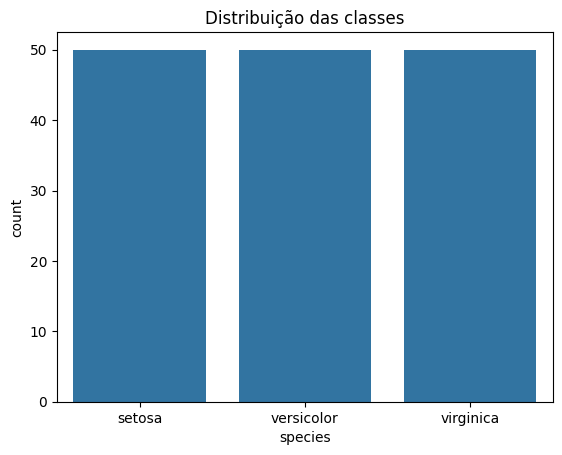

In [37]:
print("=== Distribuição das classes ===")
print(df_pd["species"].value_counts())

sns.countplot(x="species", data=df_pd)
plt.title("Distribuição das classes")
plt.show()

A distribuição das classes no dataset revela um equilíbrio perfeito entre as três espécies (setosa, versicolor e virginica), o que elimina enviesamentos na aprendizagem e favorece uma avaliação mais justa do desempenho dos modelos.

### Distribuição das Variáveis

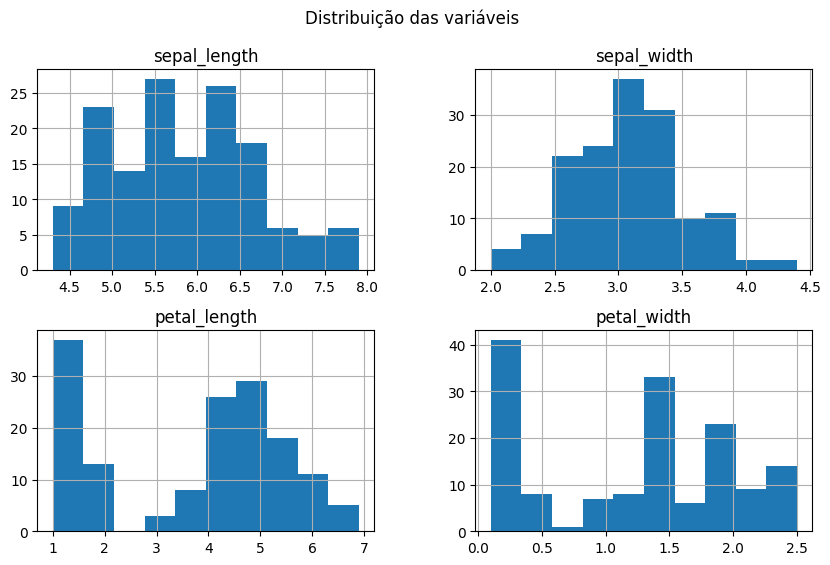

In [38]:
df_pd.hist(figsize=(10,6))
plt.suptitle("Distribuição das variáveis")
plt.show()

A distribuição das variáveis evidencia padrões distintos, destacando-se as variáveis petal_length e petal_width pela sua maior capacidade de separação entre classes, ao contrário das variáveis sepal, que apresentam maior sobreposição e menor poder discriminativo

### Relação entre as Variáveis- Scatterplot

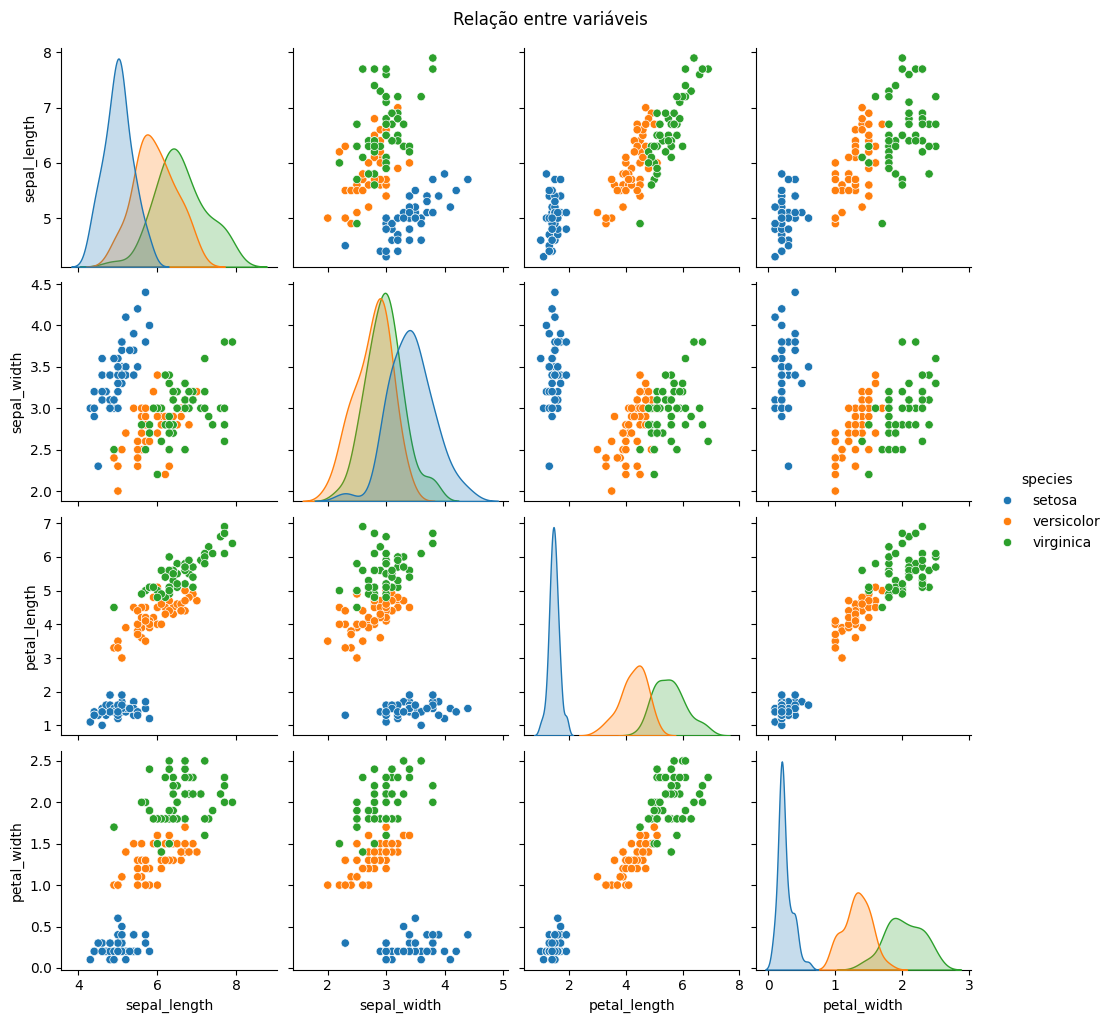

In [40]:
sns.pairplot(df_pd, hue="species")
plt.suptitle("Relação entre variáveis", y=1.02)
plt.show()

A análise da relação entre variáveis evidencia uma clara separação entre as espécies, sobretudo nas variáveis petal_length e petal_width, onde os grupos se distinguem quase sem sobreposição, ao contrário das variáveis sepal, que apresentam maior dispersão e interseção entre classes.

### Correlação entre as Variáveis

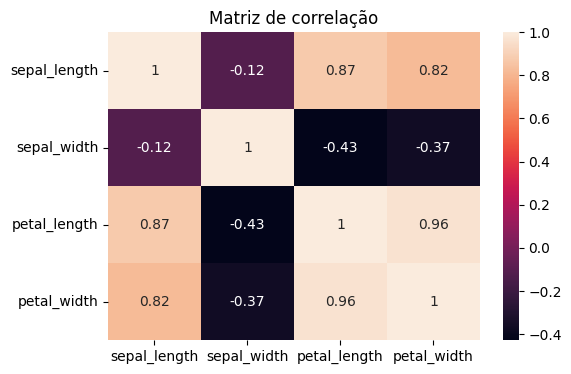

In [41]:
corr = df_pd.drop("species", axis=1).corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True)
plt.title("Matriz de correlação")
plt.show()

A matriz de correlação evidencia uma forte relação positiva entre petal_length e petal_width, indicando elevada redundância de informação, enquanto sepal_width apresenta correlações fracas ou negativas com as restantes variáveis, revelando menor relevância para a distinção entre classes.

### Conclusões da análise exploratória

- O dataset não apresenta valores em falta, garantindo qualidade dos dados.  
- As classes encontram-se equilibradas, evitando enviesamentos.  
- As variáveis *petal_length* e *petal_width* têm elevado poder discriminativo.  
- As variáveis *sepal* apresentam maior sobreposição entre classes.  
- Existe forte correlação entre *petal_length* e *petal_width*.  
- O problema apresenta baixa complexidade e elevada separabilidade.  
- Modelos mais complexos podem não trazer ganhos relevantes.  

### Definir a Variável Alvo e Variáveis Preditoras

In [43]:
# Definir a variável alvo
y = "species"

# Definir as variáveis explicativas
x = [col for col in df.columns if col != y]

print("Variável alvo:", y)
print("Variáveis preditoras:", x)

Variável alvo: species
Variáveis preditoras: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']


In [44]:
# Converter a variável alvo para fator (classificação)
df[y] = df[y].asfactor()

### Dividir a Base de Dados em Treino e Teste

In [45]:
# Dividir a base de dados em treino (80%) e teste (20%)
train, test = df.split_frame(ratios=[0.8], seed=1234)

print("Número de linhas de treino:", train.nrows)
print("Número de linhas de teste:", test.nrows)

Número de linhas de treino: 123
Número de linhas de teste: 27


### Treinar H2O AutoMl

In [46]:
# Criar e treinar o modelo AutoML
aml = H2OAutoML(
    max_runtime_secs=60,  # tempo máximo de treino
    seed=1234
)

aml.train(x=x, y=y, training_frame=train)

AutoML progress: |█
17:22:23.531: AutoML: XGBoost is not available; skipping it.
17:22:25.125: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 123.0.

██████████████████████████████████████████████████████████████| (done) 100%


Model Details
=============
H2ODeepLearningEstimator : Deep Learning
Model Key: DeepLearning_grid_1_AutoML_2_20260327_172223_model_1


Status of Neuron Layers: predicting species, 3-class classification, multinomial distribution, CrossEntropy loss, 803 weights/biases, 13,7 KB, 216.480 training samples, mini-batch size 1
    layer    units    type              dropout    l1    l2    mean_rate    rate_rms    momentum    mean_weight    weight_rms    mean_bias    bias_rms
--  -------  -------  ----------------  ---------  ----  ----  -----------  ----------  ----------  -------------  ------------  -----------  ----------
    1        4        Input             15
    2        100      RectifierDropout  50         0     0     0.00372161   0.00709665  0           -0.012394      0.222304      0.262104     0.233468
    3        3        Softmax                      0     0     0.105134     0.247663    0           -0.190764      0.776647      -1.15755     0.645793

ModelMetricsMultinomial: deeplearning
** Reported on train data. **

MSE: 0.018162188159333265
RMSE: 0.13476716276353548
LogLoss: 0.06586691522366889
Mean Per-Class Error: 0.024999999999999998
AUC table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).
AUCPR table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).

Confusion Matrix: Row labels: Actual class; Column labels: Predicted class
setosa    versicolor    virginica    Error      Rate
--------  ------------  -----------  ---------  -------
36        0             0            0          0 / 36
0         37            3            0.075      3 / 40
0         0             47           0          0 / 47
36        37            50           0.0243902  3 / 123

Top-3 Hit Ratios: 
k    hit_ratio
---  -----------
1    0.97561
2    1
3    1

ModelMetricsMultinomial: deeplearning
** Reported on cross-validation data. **

MSE: 0.025467394155045495
RMSE: 0.15958506870959294
LogLoss: 0.09032719516280409
Mean Per-Class Error: 0.023758865248226953
AUC table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).
AUCPR table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).

Confusion Matrix: Row labels: Actual class; Column labels: Predicted class
setosa    versicolor    virginica    Error      Rate
--------  ------------  -----------  ---------  -------
36        0             0            0          0 / 36
0         38            2            0.05       2 / 40
0         1             46           0.0212766  1 / 47
36        39            48           0.0243902  3 / 123

Top-3 Hit Ratios: 
k    hit_ratio
---  -----------
1    0.97561
2    1
3    1

Cross-Validation Metrics Summary: 
                         mean       sd         cv_1_valid    cv_2_valid    cv_3_valid    cv_4_valid    cv_5_valid
-----------------------  ---------  ---------  ------------  ------------  ------------  ------------  ------------
accuracy                 0.96       0.069282   0.96          1             0.84          1             1
aic                      nan        0          nan           nan           nan           nan           nan
auc                      nan        0          nan           nan           nan           nan           nan
err                      0.04       0.069282   0.04          0             0.16          0             0
err_count                1          1.73205    1             0             4             0             0
loglikelihood            nan        0          nan           nan           nan           nan           nan
logloss                  0.0990098  0.0784606  0.120259      0.0645521     0.224376      0.065

O modelo selecionado pelo H2O AutoML foi uma rede neuronal que apresentou um desempenho elevado, com elevada precisão e reduzido número de erros. A matriz de confusão evidencia que as classificações são praticamente perfeitas, sendo os poucos erros observados entre as classes versicolor e virginica, que apresentam maior semelhança. A análise da importância das variáveis confirma que as características relacionadas com as pétalas são as mais relevantes para a distinção entre espécies, em linha com a análise exploratória realizada.

### Leaderboard Completo

In [47]:
# Obter o leaderboard dos modelos treinados
lb = aml.leaderboard
lb_df = lb.as_data_frame()

print("=== Leaderboard completo ===")
print(lb_df)

C:\Users\anagil\.conda\envs\h2o_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


=== Leaderboard completo ===
                                             model_id  mean_per_class_error  \
0   DeepLearning_grid_1_AutoML_2_20260327_172223_m...              0.023759   
1   DeepLearning_grid_1_AutoML_2_20260327_172223_m...              0.036702   
2   DeepLearning_grid_1_AutoML_2_20260327_172223_m...              0.037943   
3   StackedEnsemble_AllModels_4_AutoML_2_20260327_...              0.037943   
4   DeepLearning_grid_1_AutoML_2_20260327_172223_m...              0.037943   
5   StackedEnsemble_AllModels_3_AutoML_2_20260327_...              0.037943   
6                      DRF_1_AutoML_2_20260327_172223              0.039184   
7   StackedEnsemble_AllModels_2_AutoML_2_20260327_...              0.039184   
8                      XRT_1_AutoML_2_20260327_172223              0.039184   
9   StackedEnsemble_BestOfFamily_3_AutoML_2_202603...              0.039184   
10                     GLM_1_AutoML_2_20260327_172223              0.039184   
11  StackedEnsemble_All

### 3 Melhores Modelos

In [48]:
# Mostrar os 3 melhores modelos
print("=== Top 3 modelos ===")
print(lb_df["model_id"].head(3))

=== Top 3 modelos ===
0    DeepLearning_grid_1_AutoML_2_20260327_172223_m...
1    DeepLearning_grid_1_AutoML_2_20260327_172223_m...
2    DeepLearning_grid_1_AutoML_2_20260327_172223_m...
Name: model_id, dtype: object


### Qual o Tipo dos Modelos Acima

In [50]:
# Criar uma coluna com o tipo de modelo
lb_df["tipo_modelo"] = lb_df["model_id"].str.split("_").str[0]

print("=== Tipo dos 3 melhores modelos ===")
print(lb_df[["model_id", "tipo_modelo"]].head(3))

=== Tipo dos 3 melhores modelos ===
                                            model_id   tipo_modelo
0  DeepLearning_grid_1_AutoML_2_20260327_172223_m...  DeepLearning
1  DeepLearning_grid_1_AutoML_2_20260327_172223_m...  DeepLearning
2  DeepLearning_grid_1_AutoML_2_20260327_172223_m...  DeepLearning


### Avaliar os 3 melhores modelos com F1-score

In [51]:
# Lista para guardar resultados
resultados = []

# Obter os IDs dos 3 melhores modelos
top3_ids = lb_df["model_id"].head(3).tolist()

for model_id in top3_ids:
    # Ir buscar o modelo
    model = h2o.get_model(model_id)
    
    # Fazer previsões no conjunto de teste
    preds = model.predict(test).as_data_frame()
    
    # Valores reais
    y_true = test[y].as_data_frame()[y]
    
    # Calcular F1-score ponderado
    f1 = f1_score(y_true, preds["predict"], average="weighted")
    
    # Guardar resultados
    resultados.append({
        "Modelo": model_id,
        "F1_score": f1
    })

# Converter para DataFrame
df_f1 = pd.DataFrame(resultados).sort_values(by="F1_score", ascending=False)

print("=== Comparação dos 3 melhores modelos com F1-score ===")
print(df_f1)

deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%


C:\Users\anagil\.conda\envs\h2o_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\anagil\.conda\envs\h2o_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%


C:\Users\anagil\.conda\envs\h2o_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\anagil\.conda\envs\h2o_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


deeplearning prediction progress: |██████████████████████████████████████████████| (done) 100%


C:\Users\anagil\.conda\envs\h2o_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"
C:\Users\anagil\.conda\envs\h2o_env\Lib\site-packages\h2o\frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


=== Comparação dos 3 melhores modelos com F1-score ===
                                              Modelo  F1_score
0  DeepLearning_grid_1_AutoML_2_20260327_172223_m...  0.964634
2  DeepLearning_grid_1_AutoML_2_20260327_172223_m...  0.964634
1  DeepLearning_grid_1_AutoML_2_20260327_172223_m...  0.897603


Os resultados mostram que os três melhores modelos pertencem à mesma família (Deep Learning), apresentando valores de F1-score muito elevados e próximos entre si. Isto indica que o processo de AutoML convergiu para soluções semelhantes, explorando diferentes configurações da mesma abordagem. No entanto, esta convergência não significa necessariamente superioridade absoluta deste tipo de modelo, mas antes uma otimização interna dentro das opções exploradas pelo algoritmo.

### Gráfico com os 3 Melhores Modelos

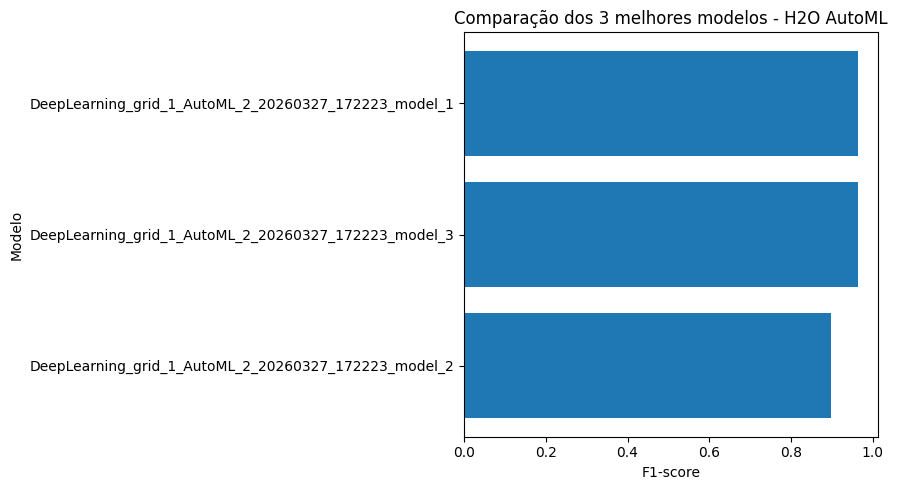

In [52]:
plt.figure(figsize=(9, 5))
plt.barh(df_f1["Modelo"], df_f1["F1_score"])
plt.xlabel("F1-score")
plt.ylabel("Modelo")
plt.title("Comparação dos 3 melhores modelos - H2O AutoML")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Análise Automática dos 3 Melhores Modelos

In [63]:
print("=== Análise dos 3 melhores modelos ===\n")

for i, row in df_f1.iterrows():
    nome = row["Modelo"]
    score = row["F1_score"]
    
    if "DeepLearning" in nome:
        tipo = "Rede neuronal"
    elif "StackedEnsemble" in nome:
        tipo = "Ensemble"
    elif "GBM" in nome:
        tipo = "Gradient Boosting Machine"
    elif "GLM" in nome:
        tipo = "Modelo linear generalizado"
    elif "XGBoost" in nome:
        tipo = "Extreme Gradient Boosting"
    elif "DRF" in nome:
        tipo = "Random Forest"
    else:
        tipo = "Outro"
    
    print(f"Modelo: {nome}")
    print(f"Tipo: {tipo}")
    print(f"F1-score: {score:.4f}")
    print("-" * 60)

=== Análise dos 3 melhores modelos ===

Modelo: DeepLearning_grid_1_AutoML_2_20260327_172223_model_1
Tipo: Rede neuronal
F1-score: 0.9646
------------------------------------------------------------
Modelo: DeepLearning_grid_1_AutoML_2_20260327_172223_model_3
Tipo: Rede neuronal
F1-score: 0.9646
------------------------------------------------------------
Modelo: DeepLearning_grid_1_AutoML_2_20260327_172223_model_2
Tipo: Rede neuronal
F1-score: 0.8976
------------------------------------------------------------


### O Melhor Modelo

In [57]:
leader = aml.leader

print("=== Melhor modelo ===")
leader.model_id

=== Melhor modelo ===


'DeepLearning_grid_1_AutoML_2_20260327_172223_model_1'

In [58]:
# Avaliar o melhor modelo no conjunto de teste
perf = leader.model_performance(test)

print("=== Performance do melhor modelo ===")
perf

=== Performance do melhor modelo ===


ModelMetricsMultinomial: deeplearning
** Reported on test data. **

MSE: 0.03520689848707139
RMSE: 0.18763501402209395
LogLoss: 0.11297952591379586
Mean Per-Class Error: 0.03333333333333333
AUC table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).
AUCPR table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).

Confusion Matrix: Row labels: Actual class; Column labels: Predicted class
setosa    versicolor    virginica    Error     Rate
--------  ------------  -----------  --------  ------
14        0             0            0         0 / 14
0         9             1            0.1       1 / 10
0         0             3            0         0 / 3
14        9             4            0.037037  1 / 27

Top-3 Hit Ratios: 
k    hit_ratio
---  -----------
1    0.962963
2    1
3    1

O melhor modelo identificado apresentou um desempenho elevado, com uma taxa de erro reduzida (≈3%) e previsões consistentes. A matriz de confusão evidencia classificações praticamente perfeitas, sendo o único erro observado entre as classes versicolor e virginica, que apresentam maior proximidade. Os resultados confirmam a elevada capacidade do modelo para generalizar, mantendo um nível de precisão elevado nos dados de teste.

In [59]:
# Matriz de confusão
print("=== Matriz de confusão ===")
perf.confusion_matrix()

=== Matriz de confusão ===


setosa,versicolor,virginica,Error,Rate
14.0,0.0,0.0,0.0,0 / 14
0.0,9.0,1.0,0.1,1 / 10
0.0,0.0,3.0,0.0,0 / 3
14.0,9.0,4.0,0.0370370,1 / 27


In [61]:
# Alguns modelos permitem ver a importância das variáveis
try:
    varimp = leader.varimp(use_pandas=True)
    print("=== Importância das variáveis ===")
    print(varimp)
except:
    print("O melhor modelo não disponibiliza importância das variáveis.")

=== Importância das variáveis ===
       variable  relative_importance  scaled_importance  percentage
0   petal_width             1.000000           1.000000    0.347469
1  petal_length             0.983845           0.983845    0.341856
2   sepal_width             0.480916           0.480916    0.167104
3  sepal_length             0.413190           0.413190    0.143571


### Explicação Visual do Melhor Modelo

# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## DeepLearning_grid_1_AutoML_2_20260327_172223_model_1

setosa,versicolor,virginica,Error,Rate
14.0,0.0,0.0,0.0,0 / 14
0.0,9.0,1.0,0.1,1 / 10
0.0,0.0,3.0,0.0,0 / 3
14.0,9.0,4.0,0.0370370,1 / 27


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

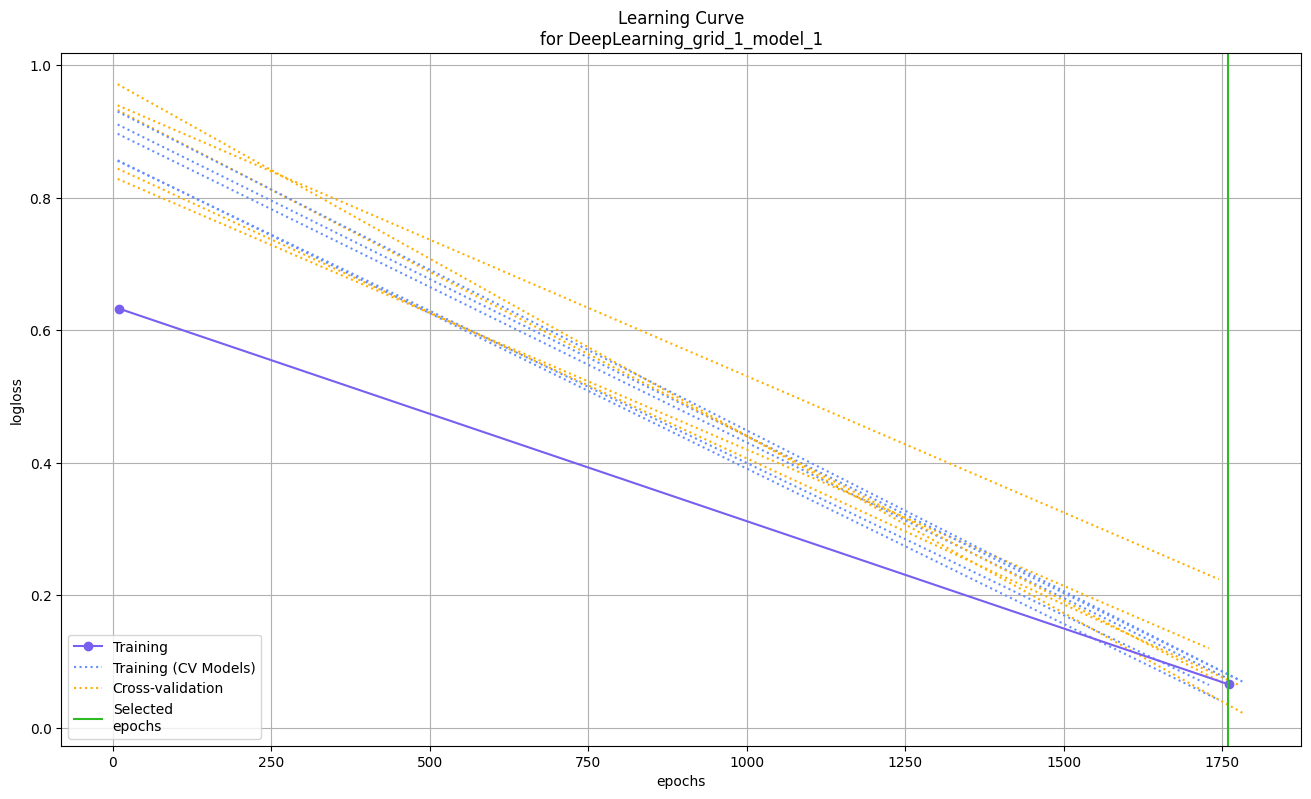

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

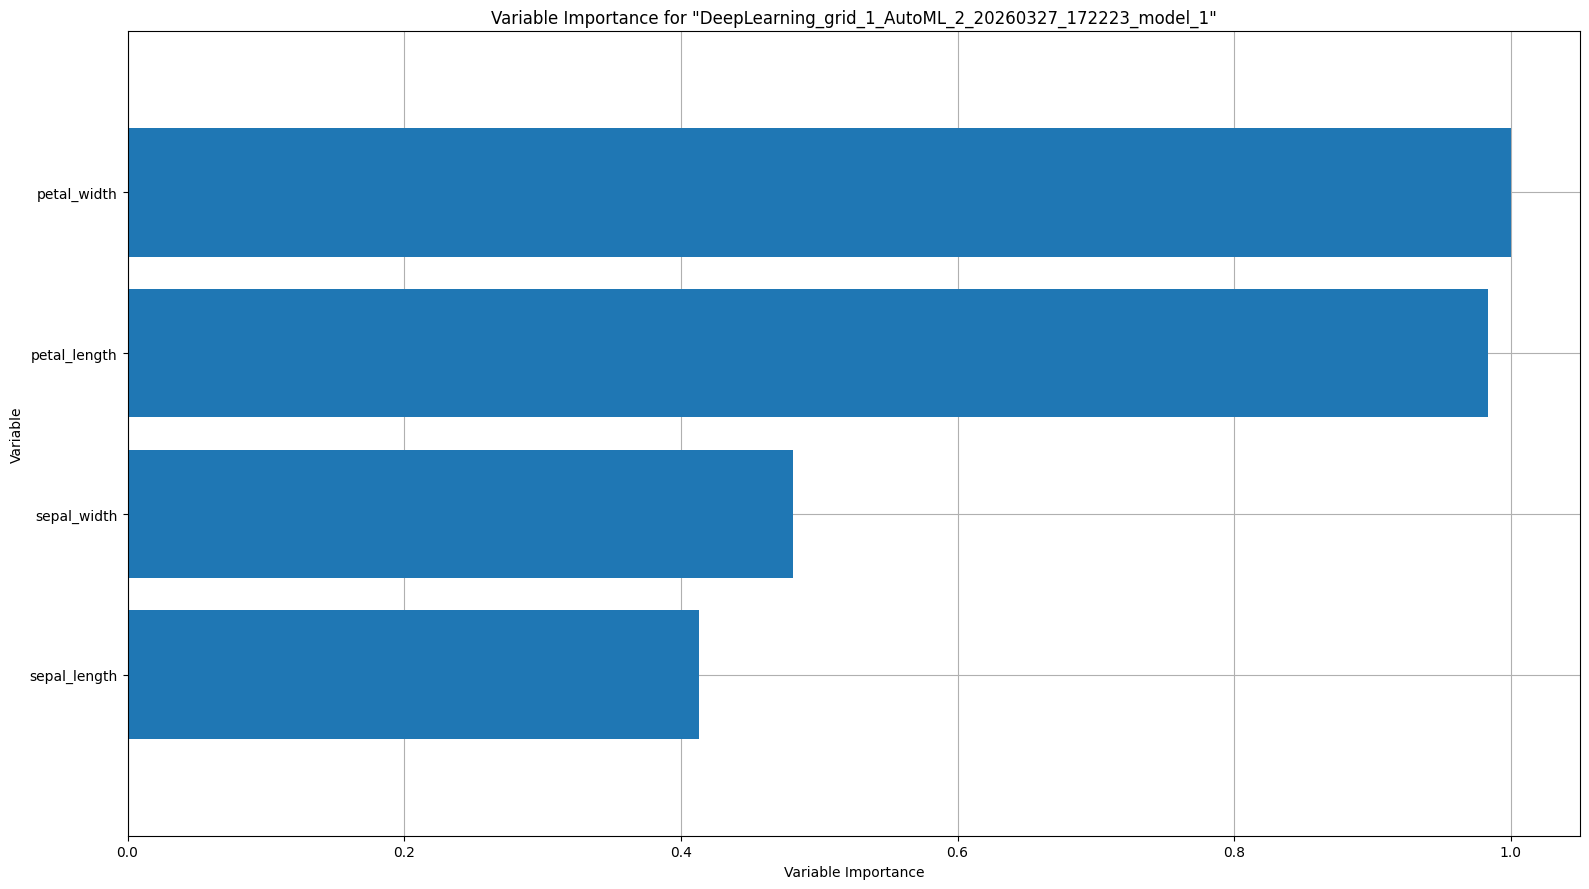

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

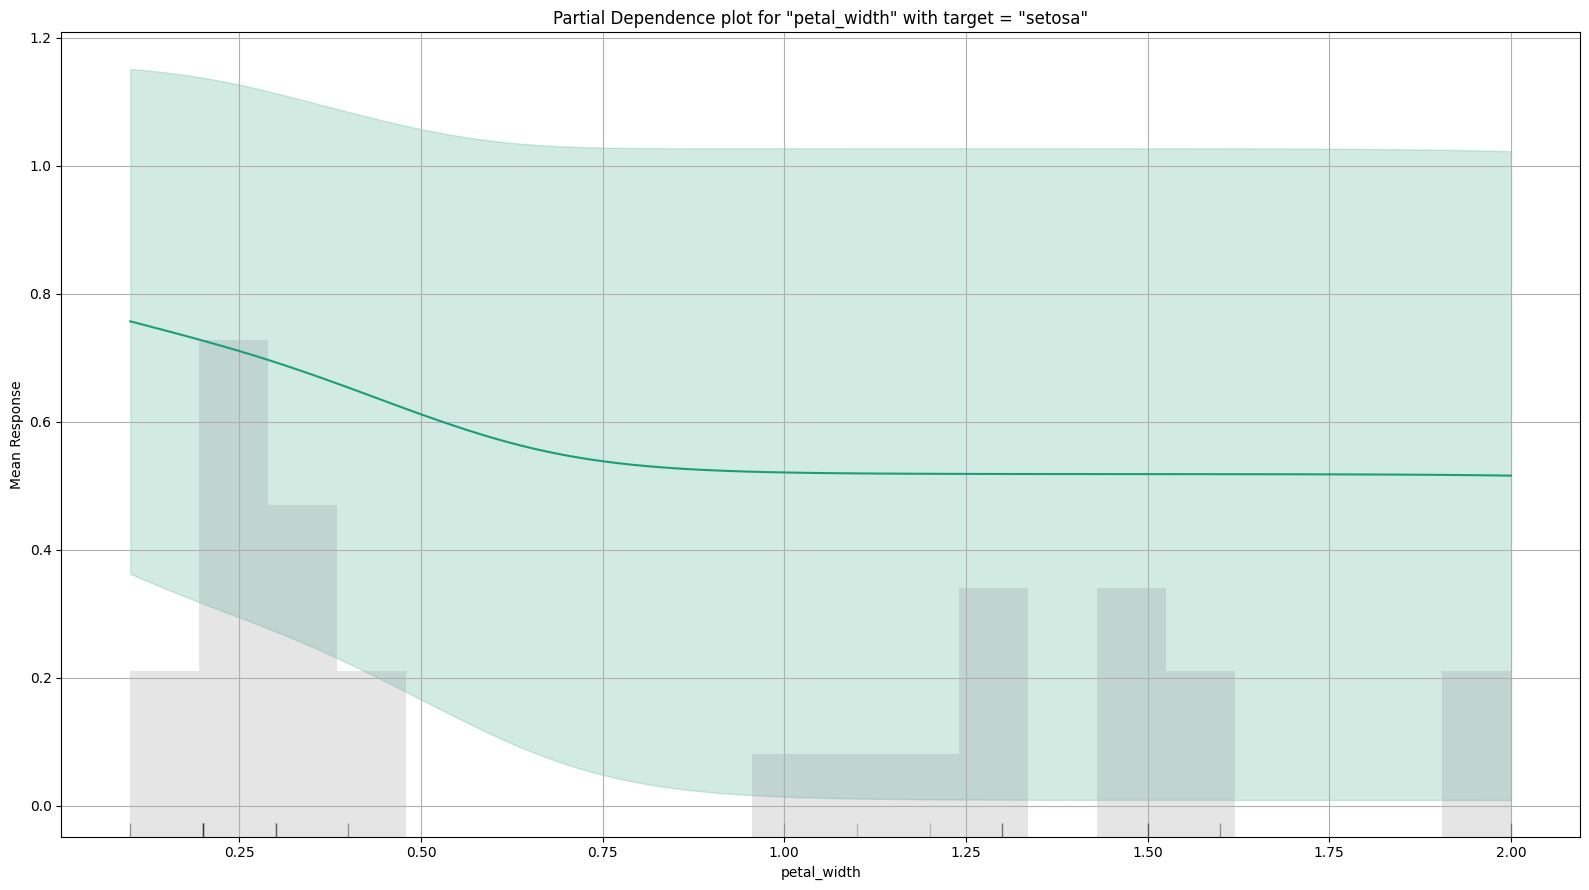

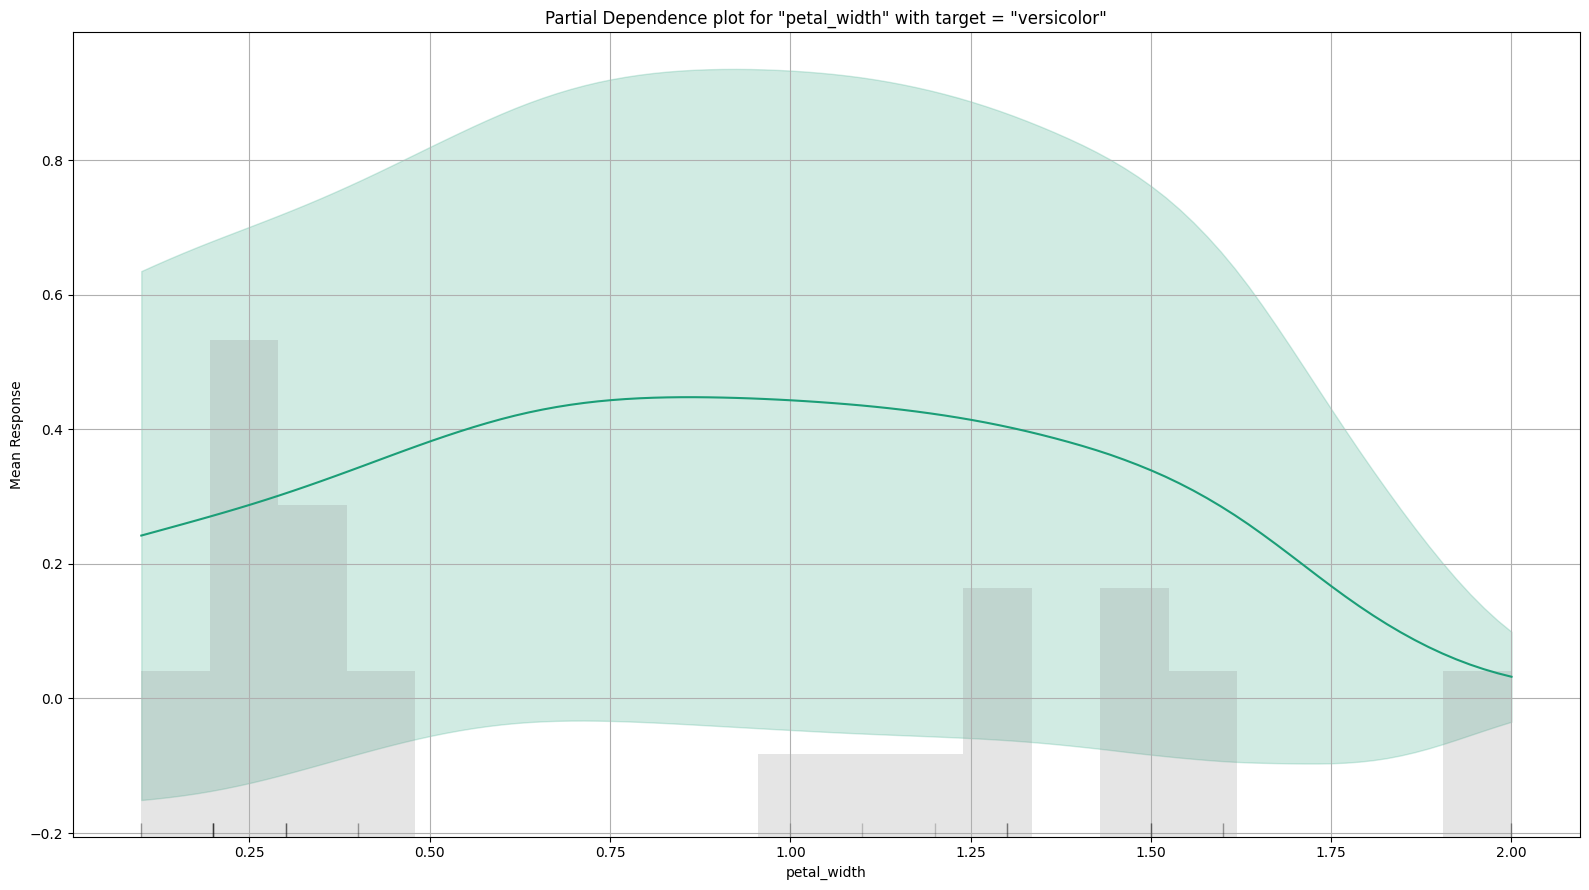

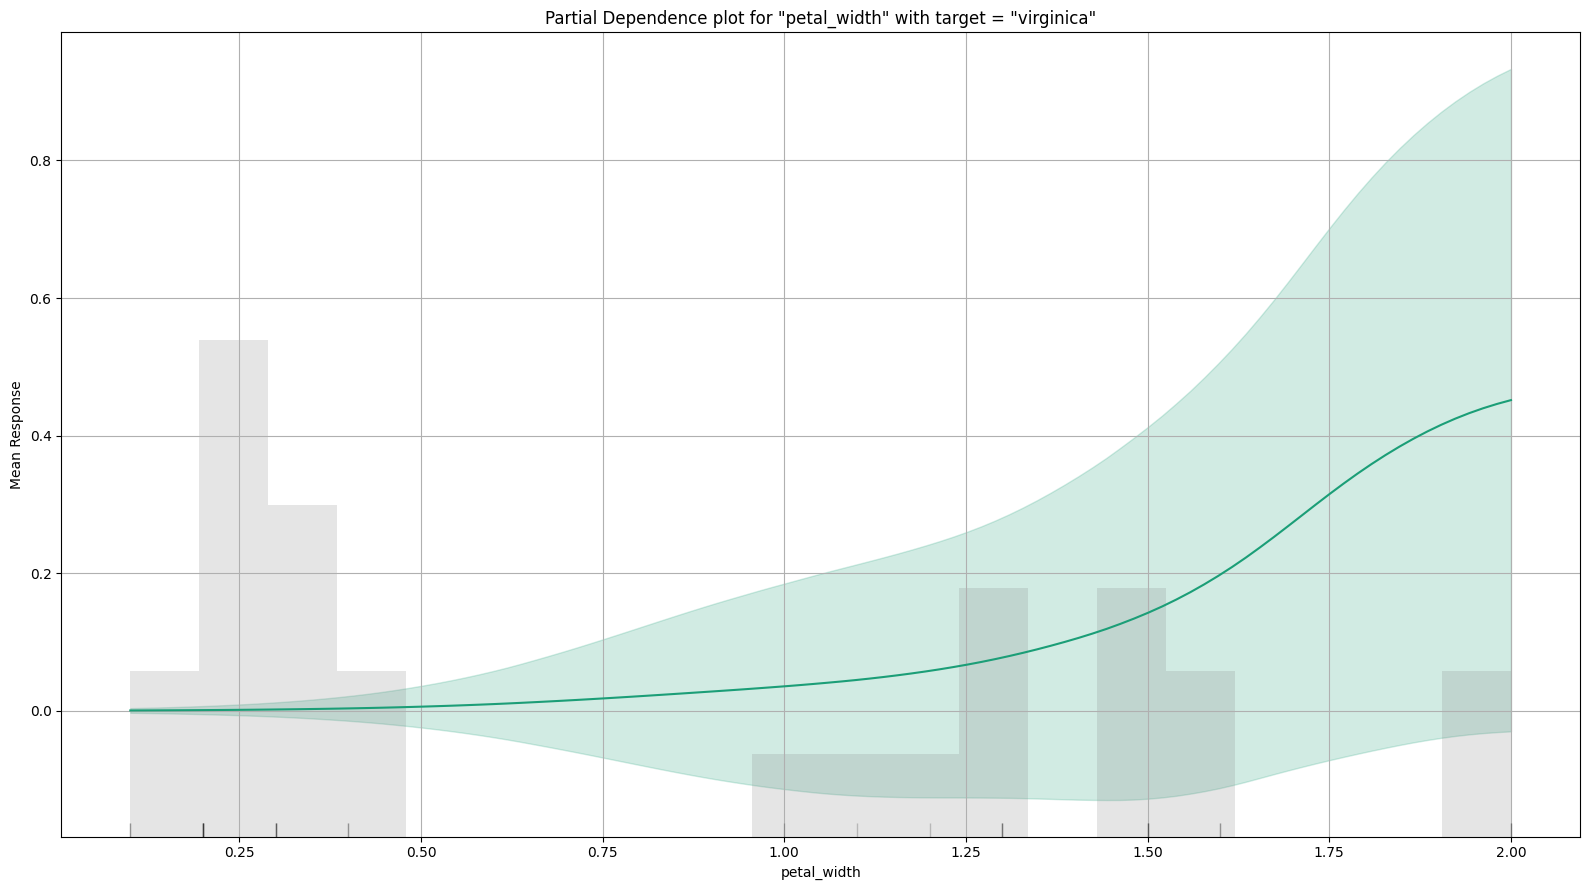

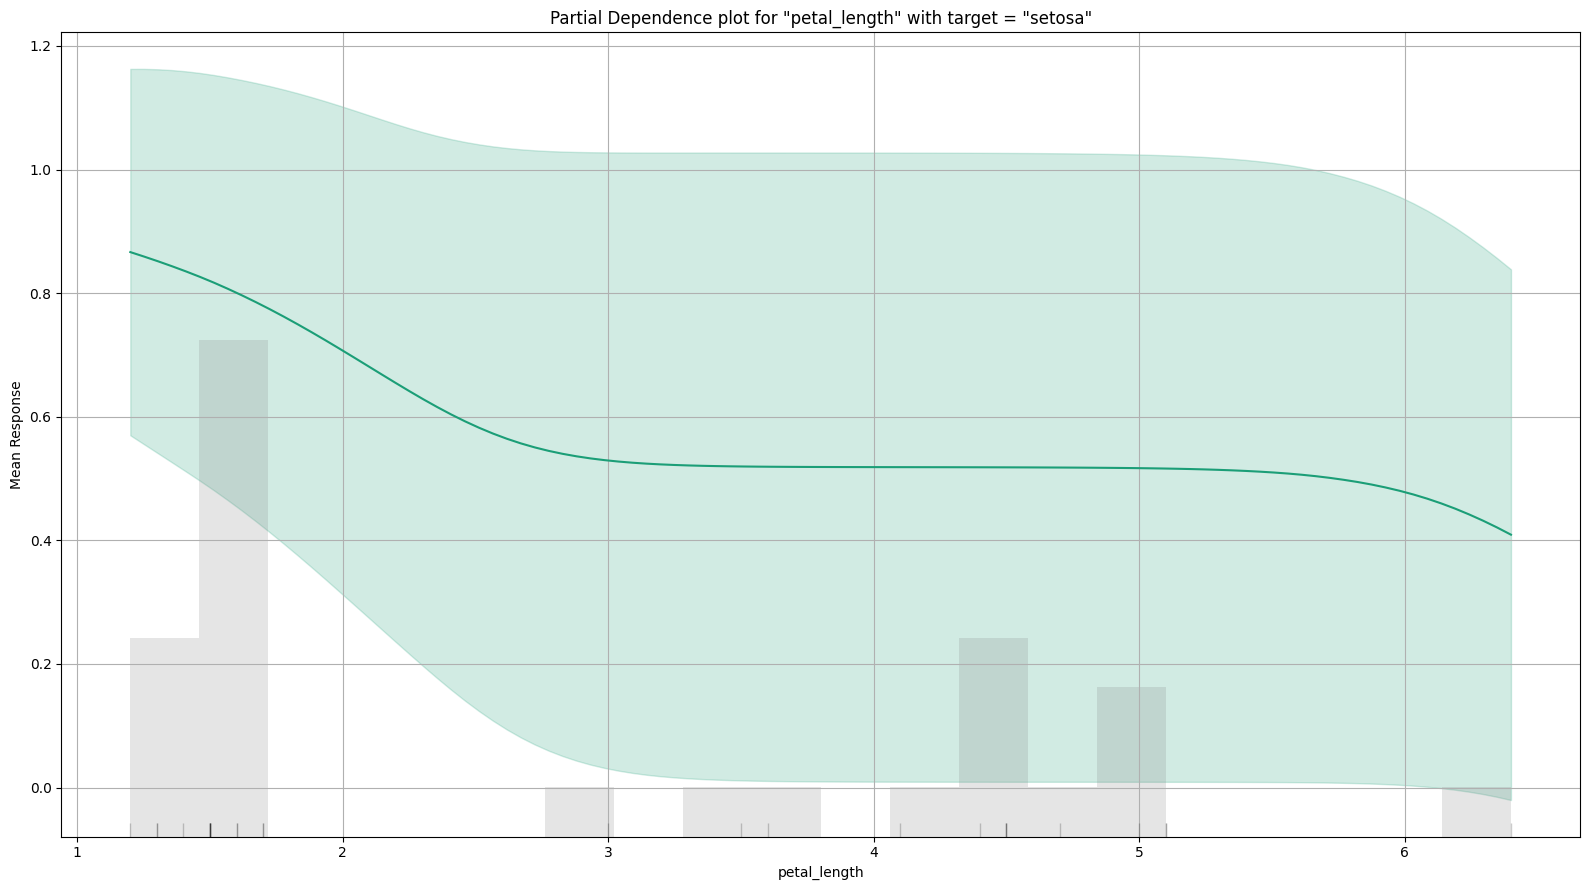

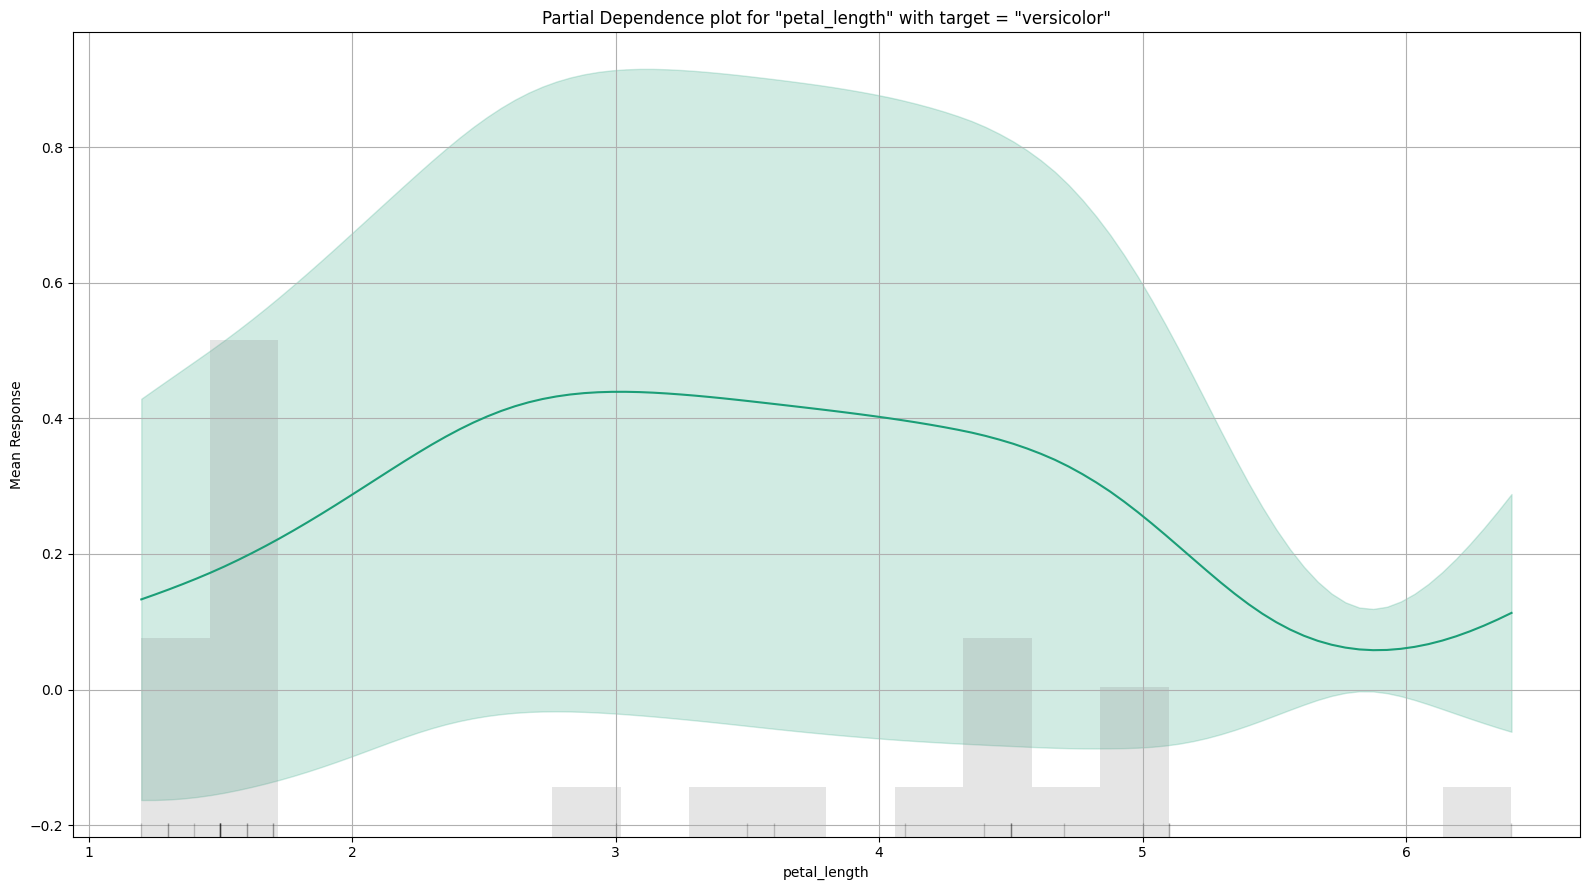

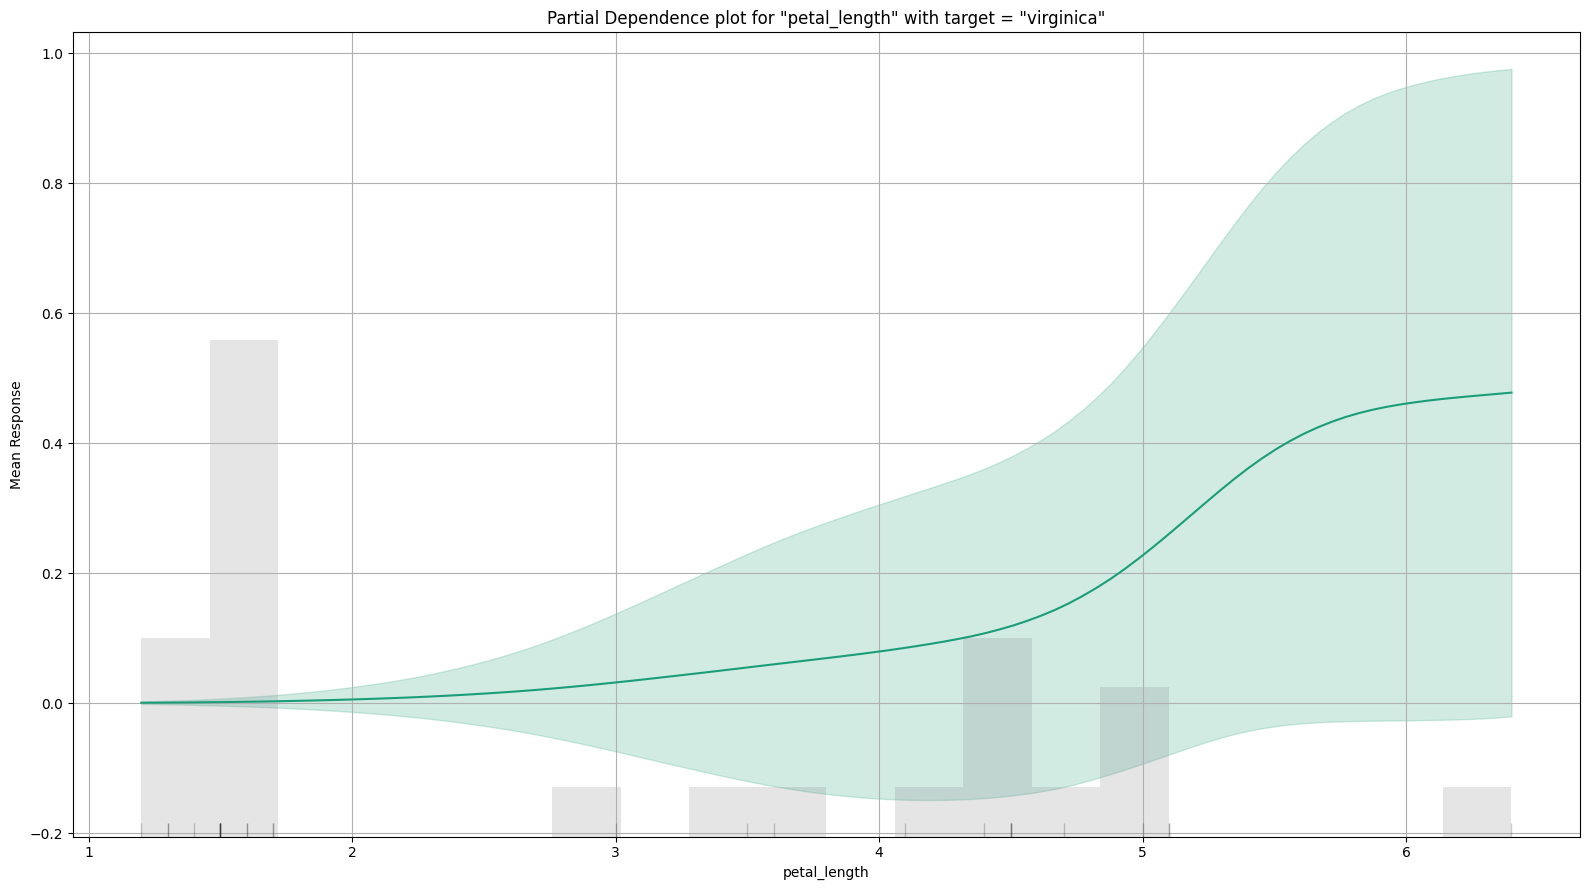

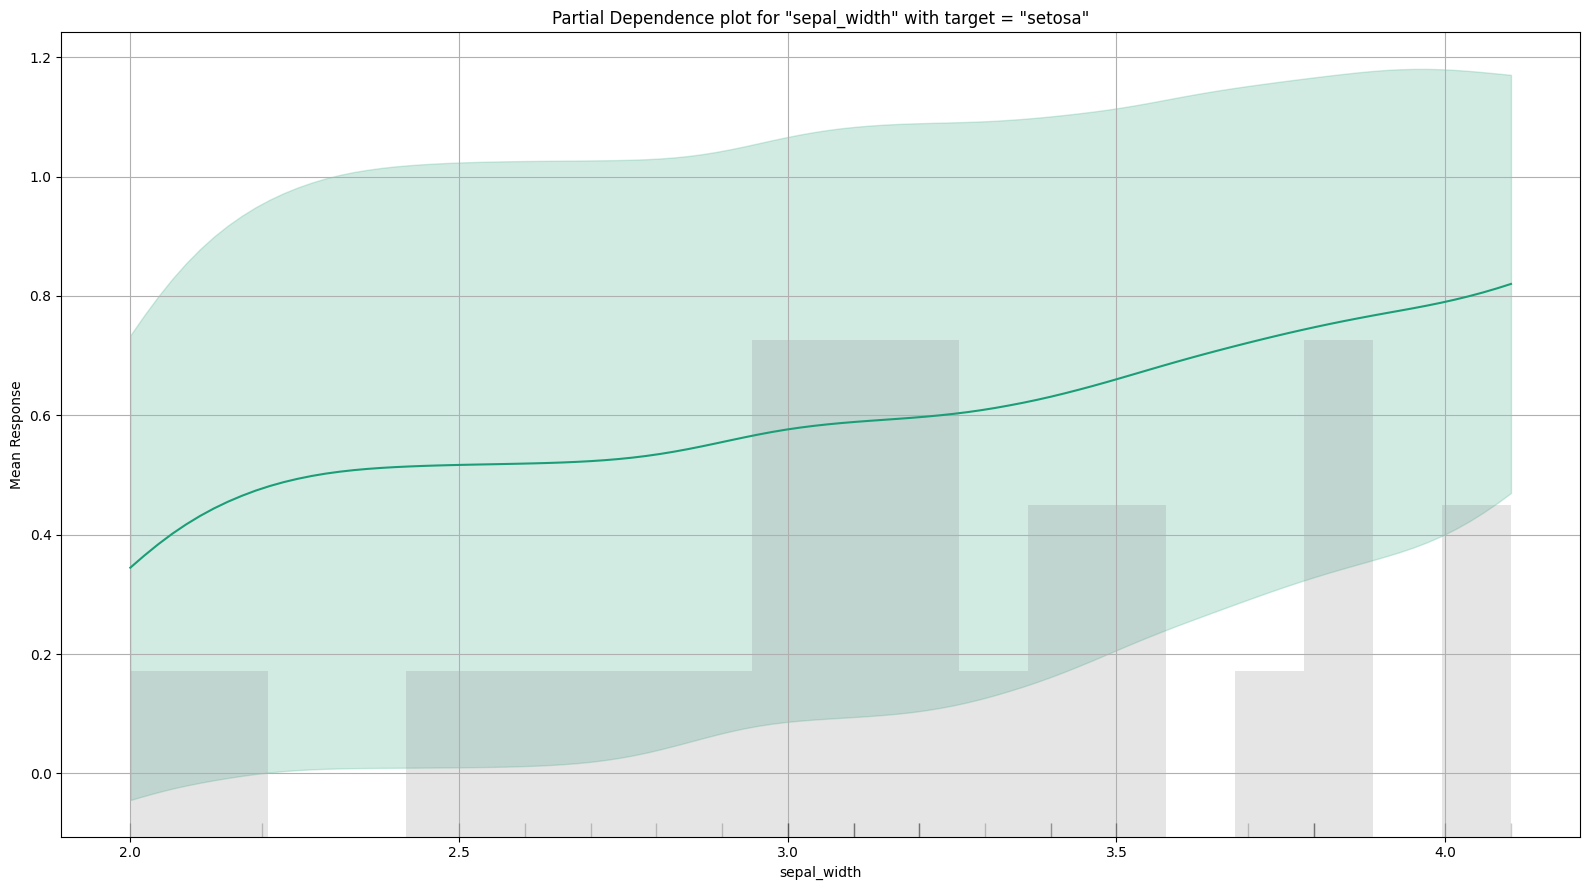

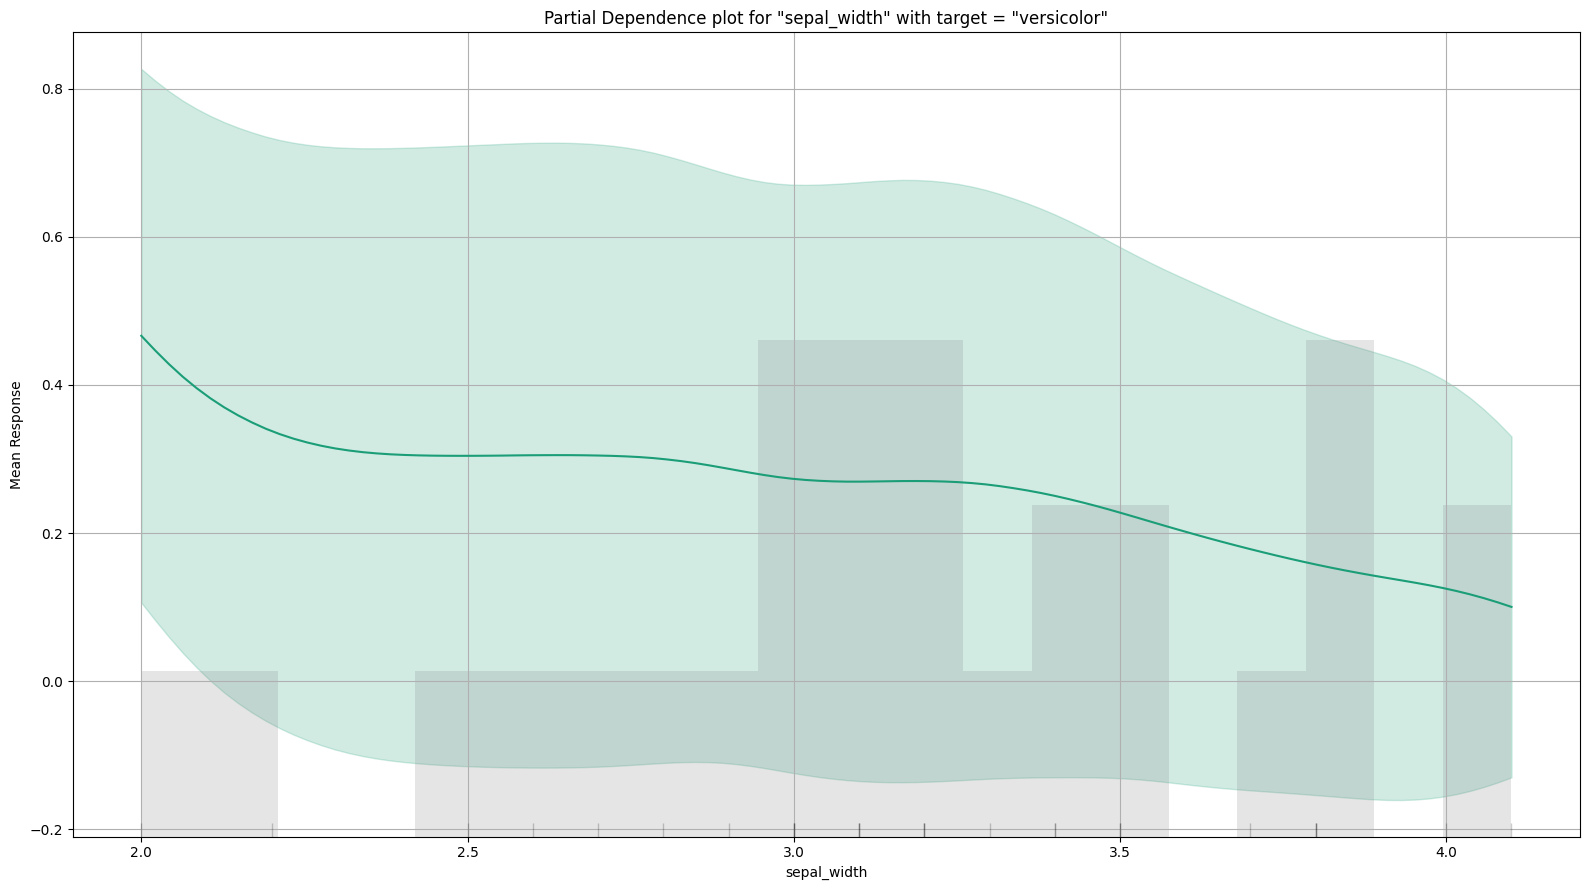

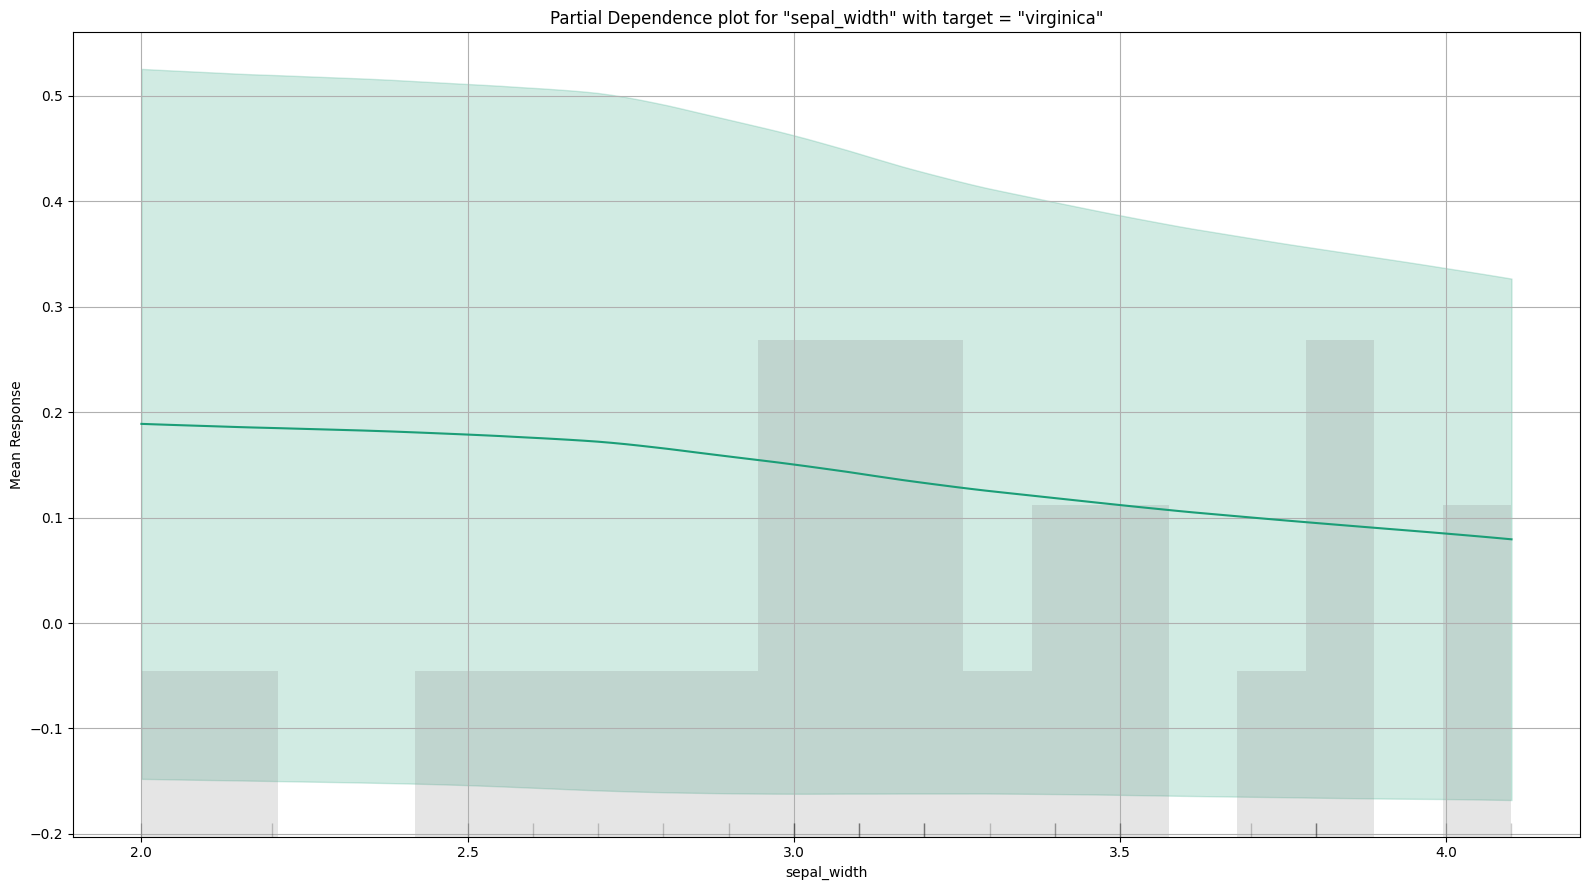

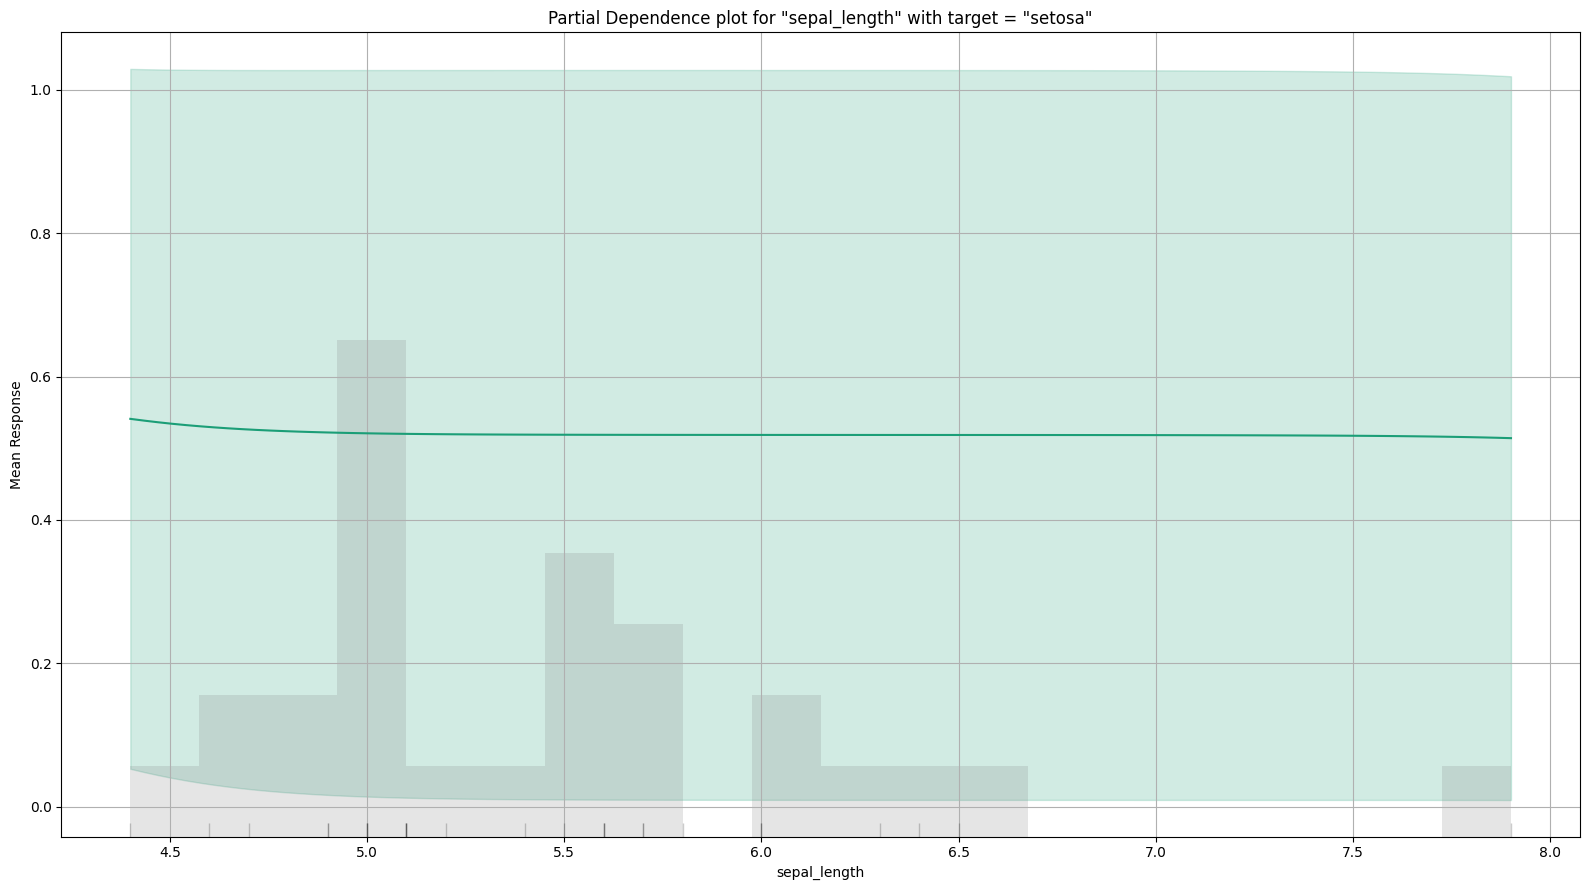

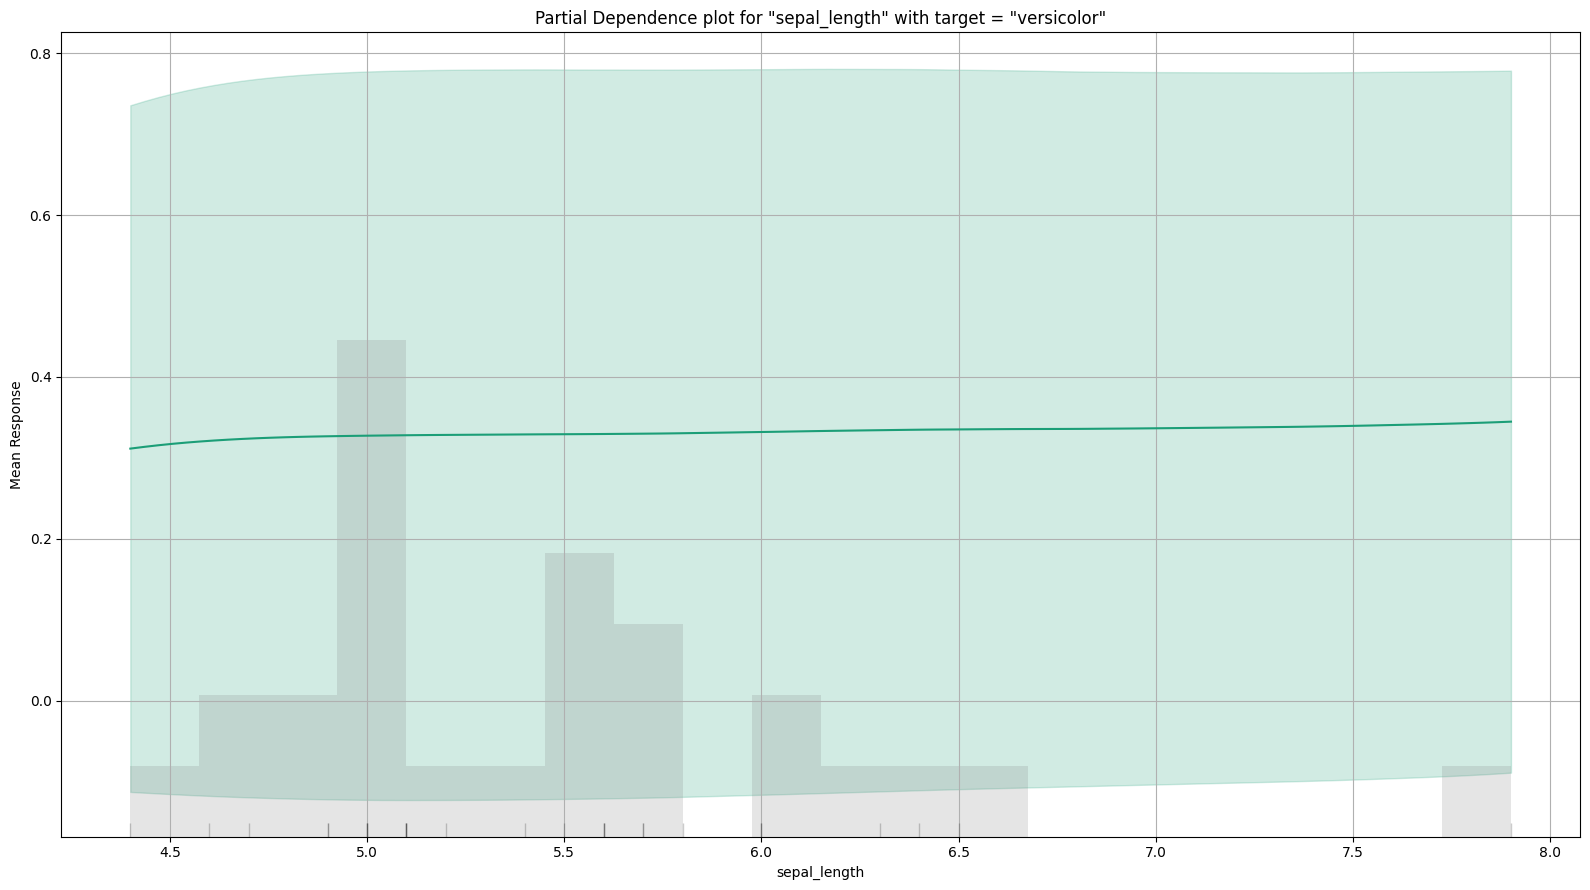

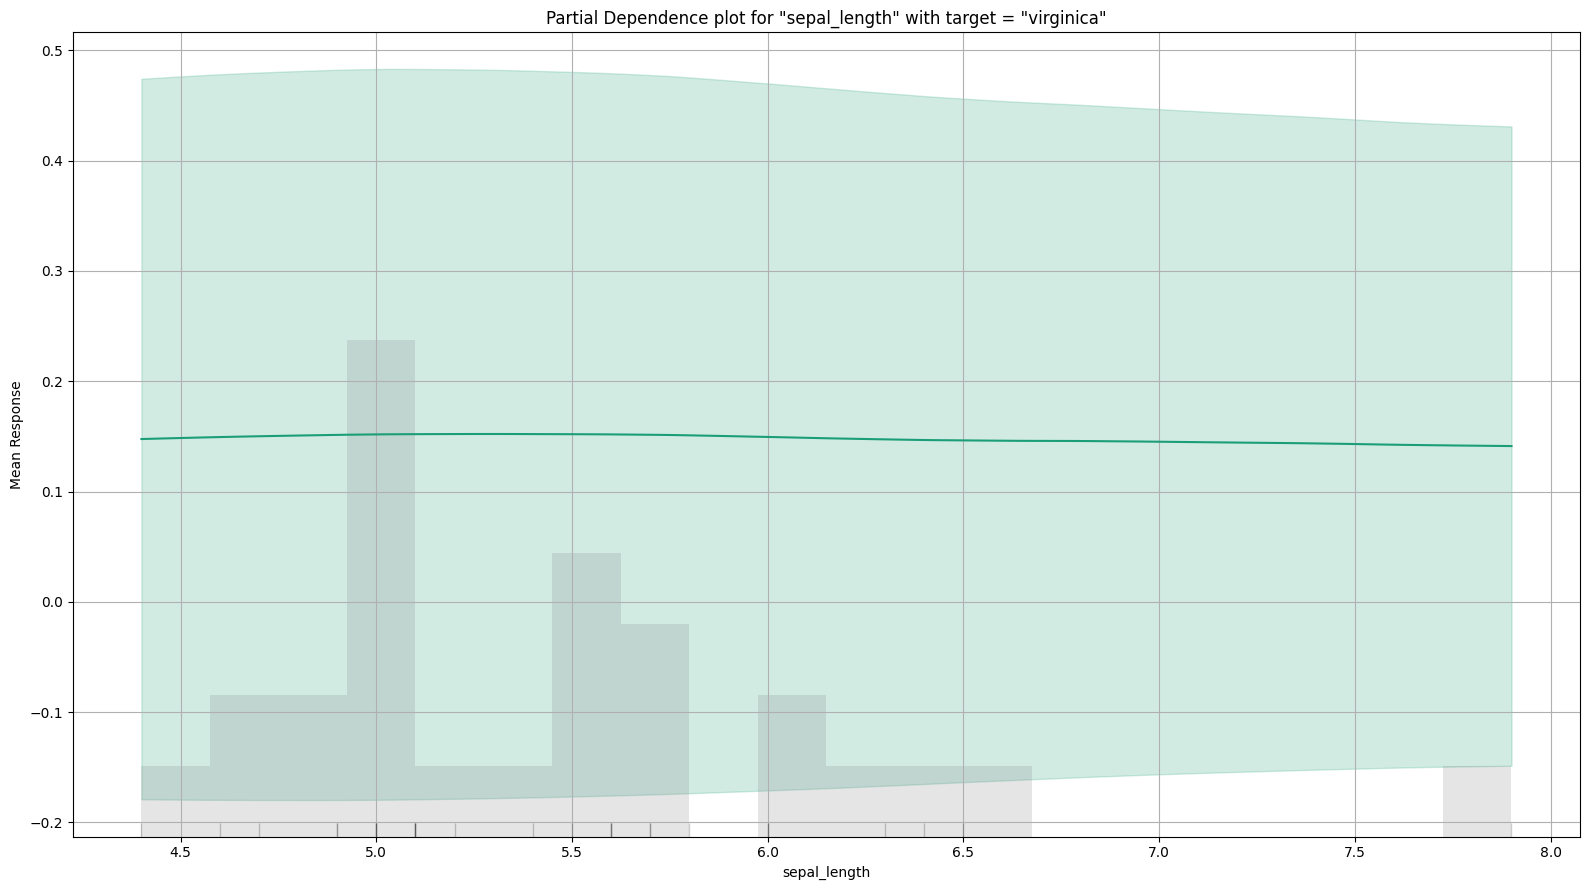

# Confusion Matrix

> Confusion matrix shows a predicted class vs an actual class.

## DeepLearning_grid_1_AutoML_2_20260327_172223_model_1

setosa,versicolor,virginica,Error,Rate
14.0,0.0,0.0,0.0,0 / 14
0.0,9.0,1.0,0.1,1 / 10
0.0,0.0,3.0,0.0,0 / 3
14.0,9.0,4.0,0.0370370,1 / 27


# Learning Curve Plot

> Learning curve plot shows the loss function/metric dependent on number of iterations or trees for tree-based algorithms. This plot can be useful for determining whether the model overfits.

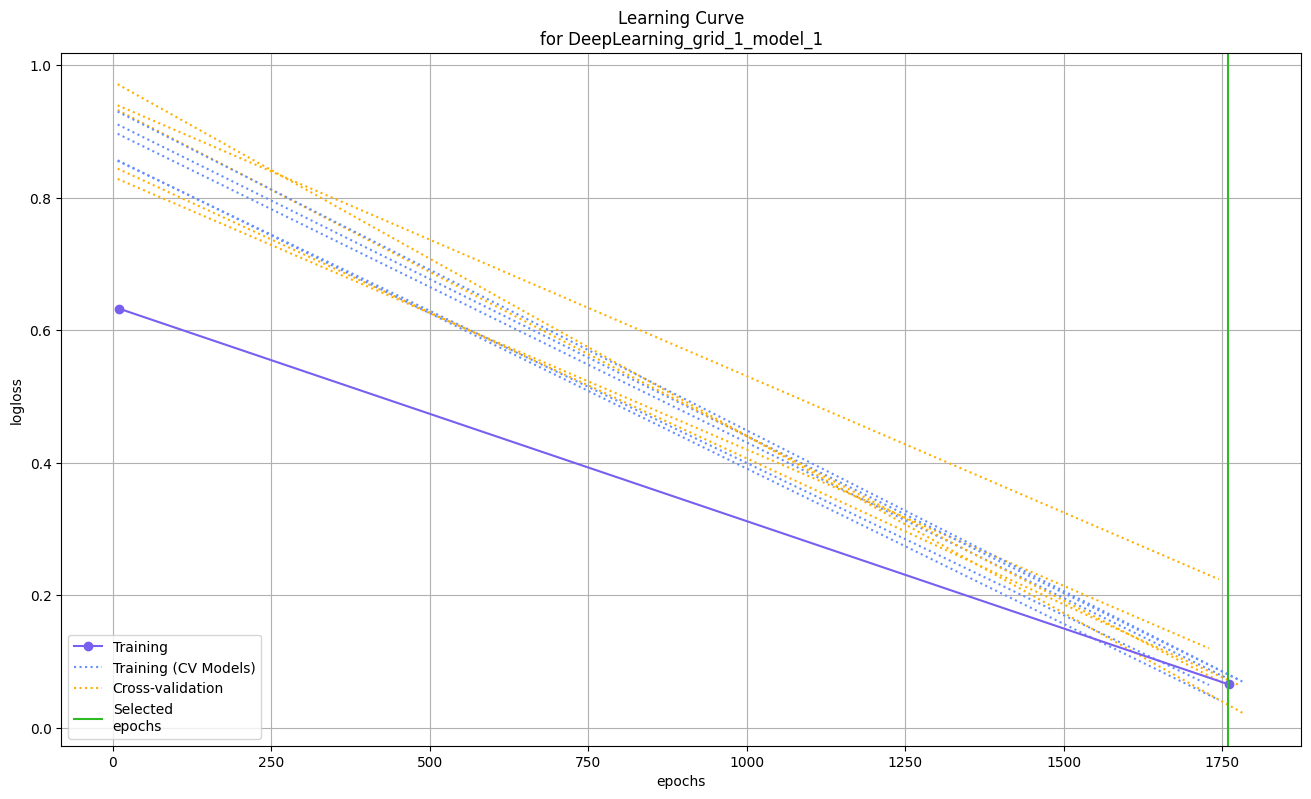

# Variable Importance

> The variable importance plot shows the relative importance of the most important variables in the model.

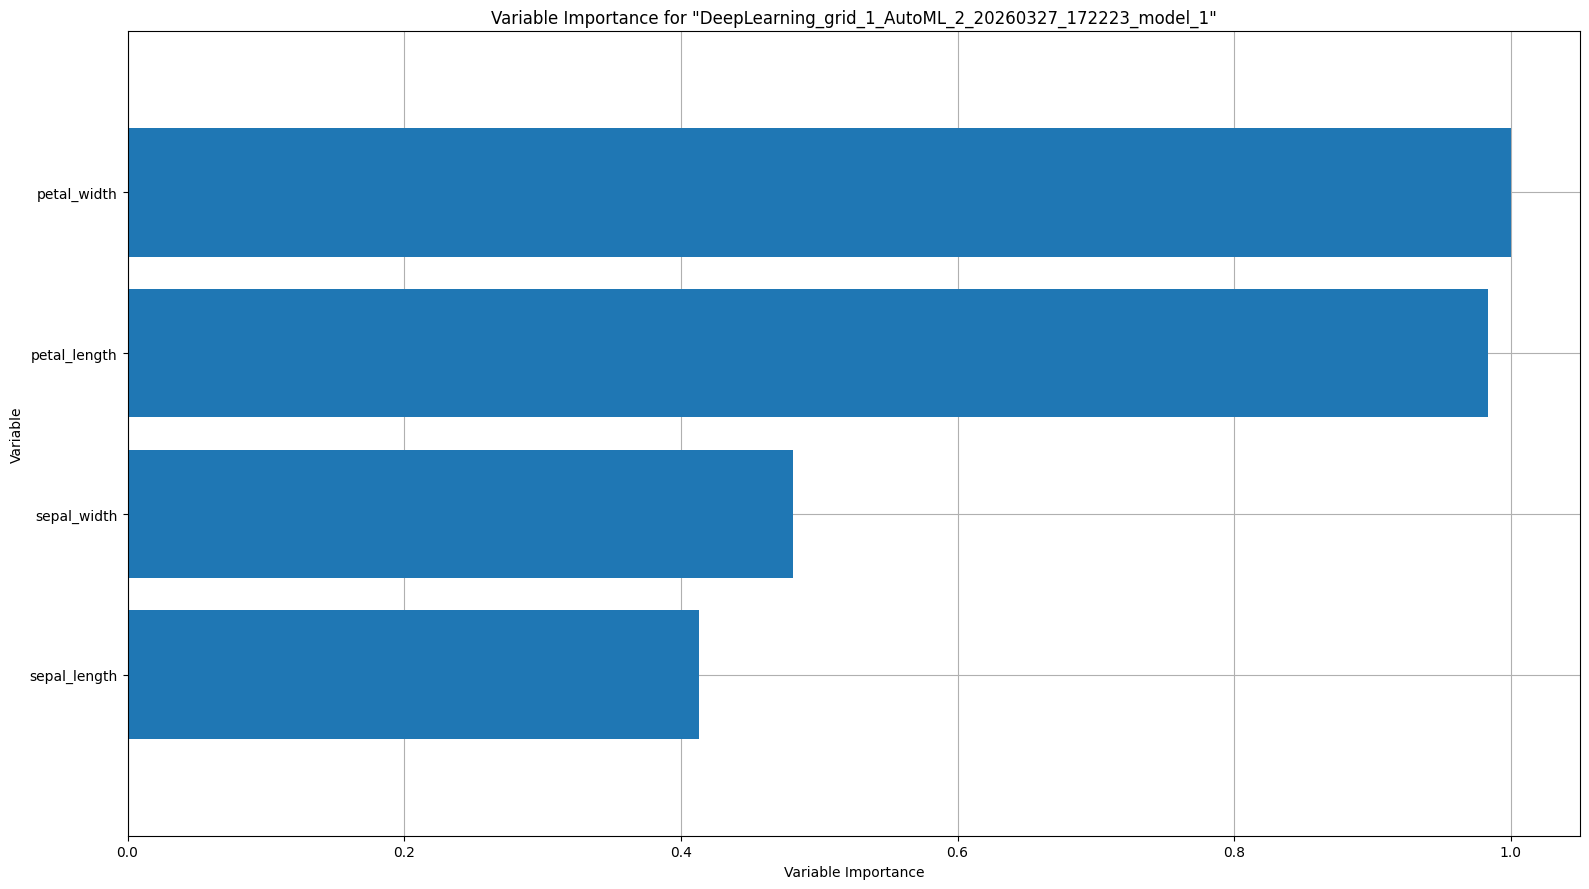

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

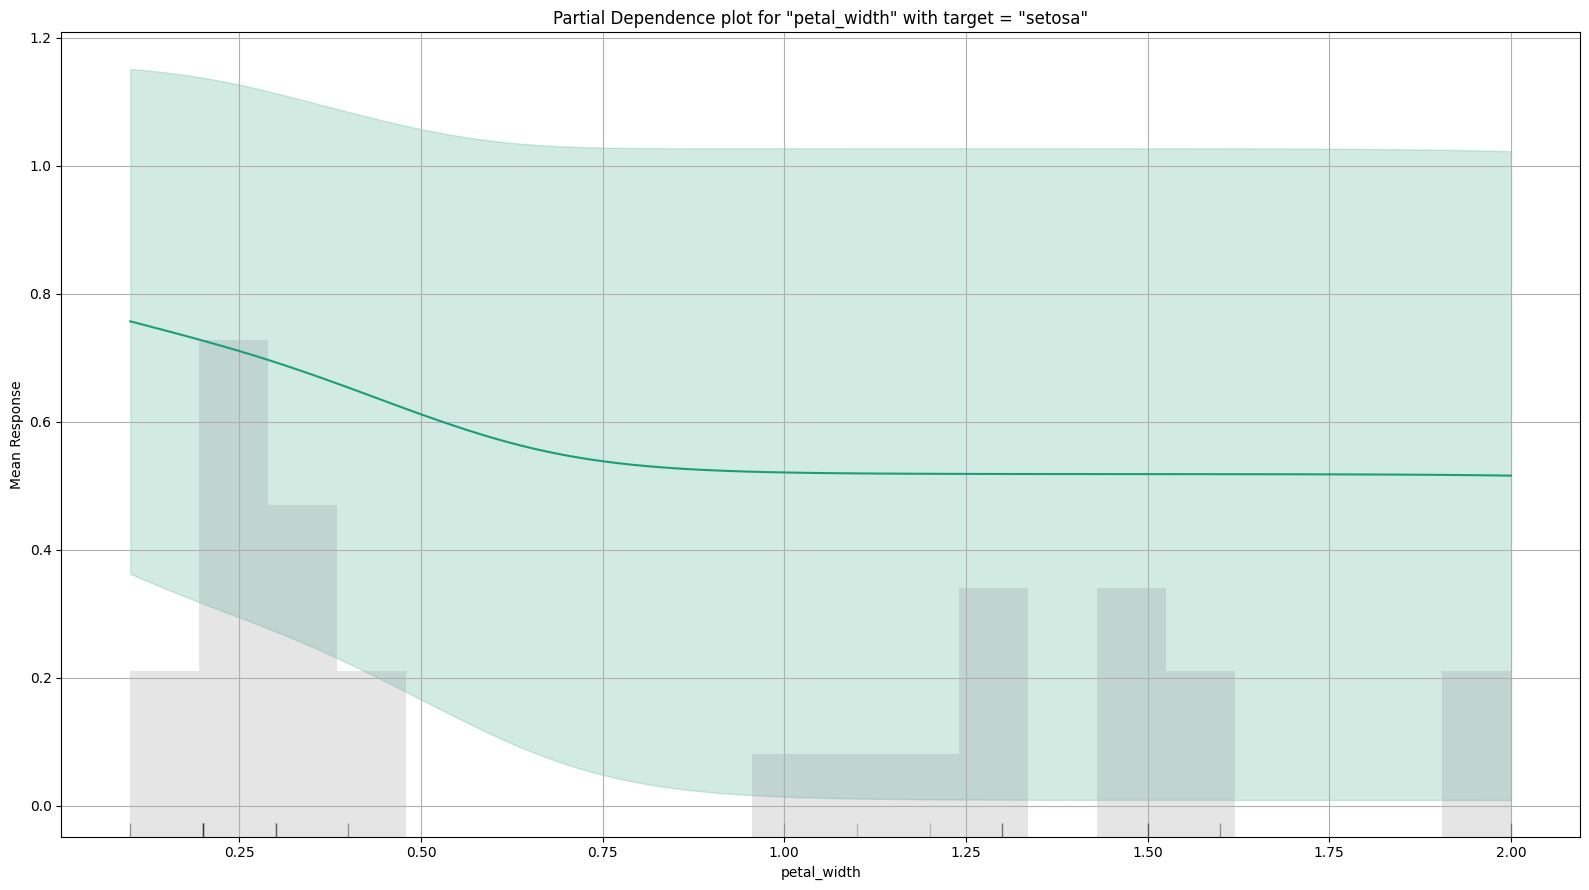

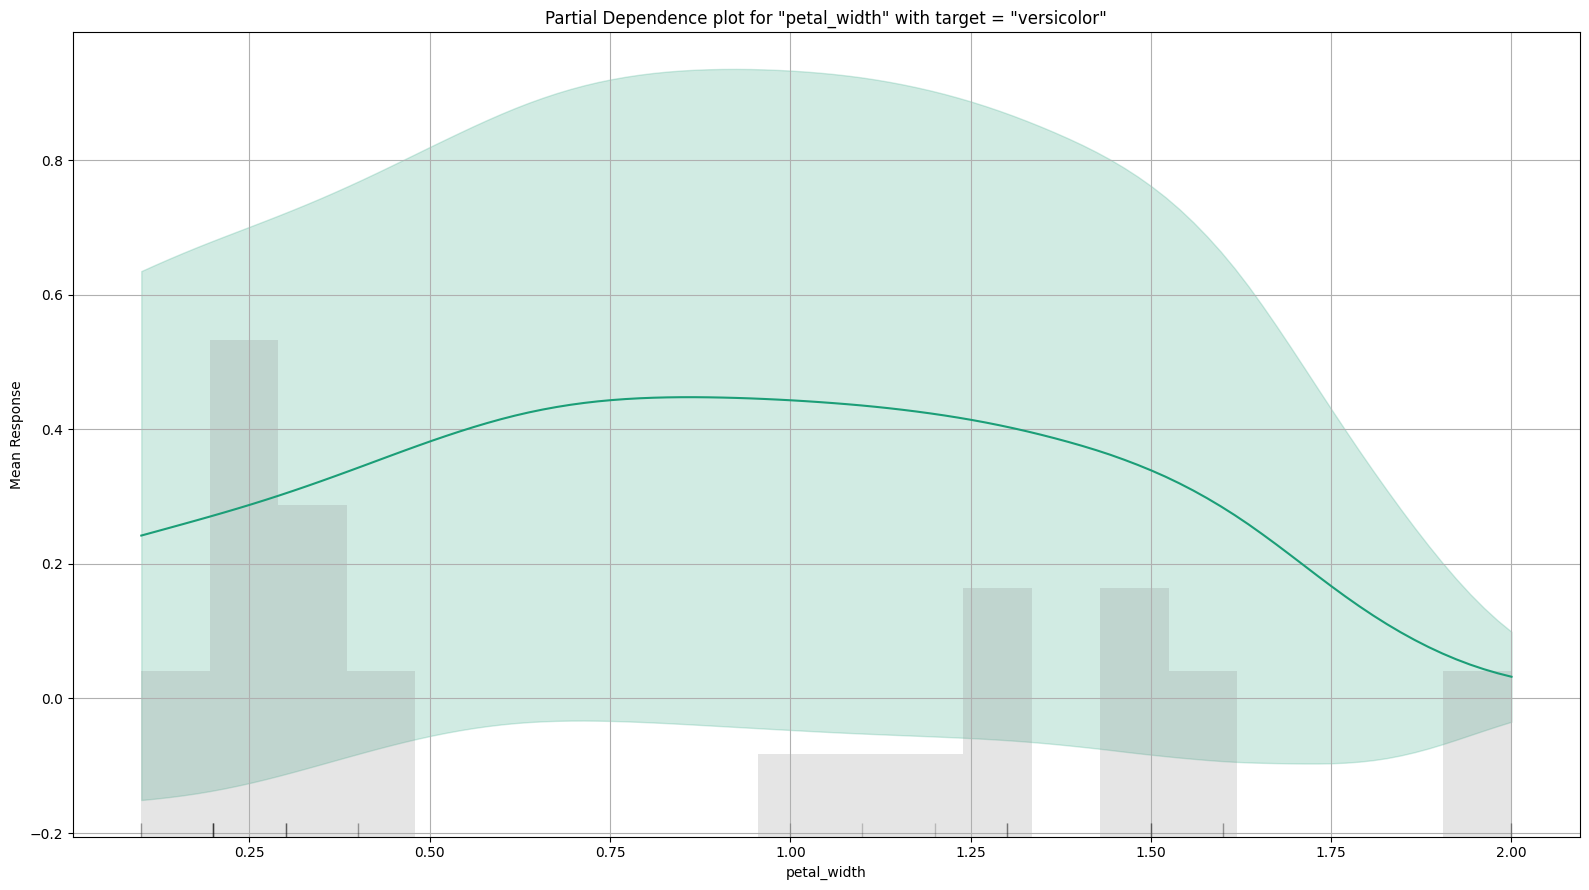

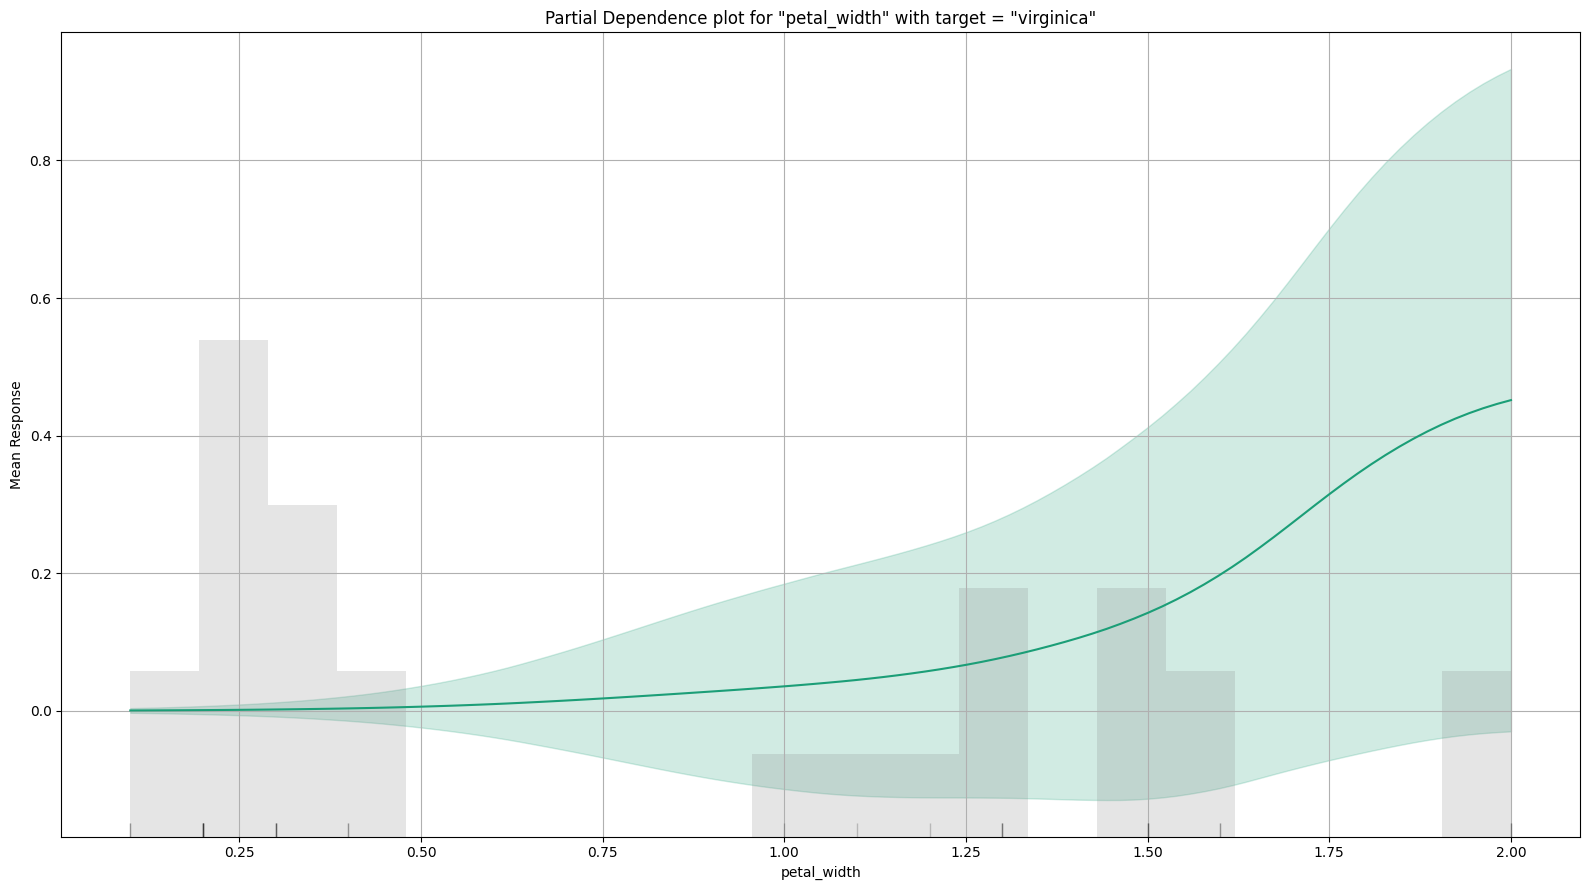

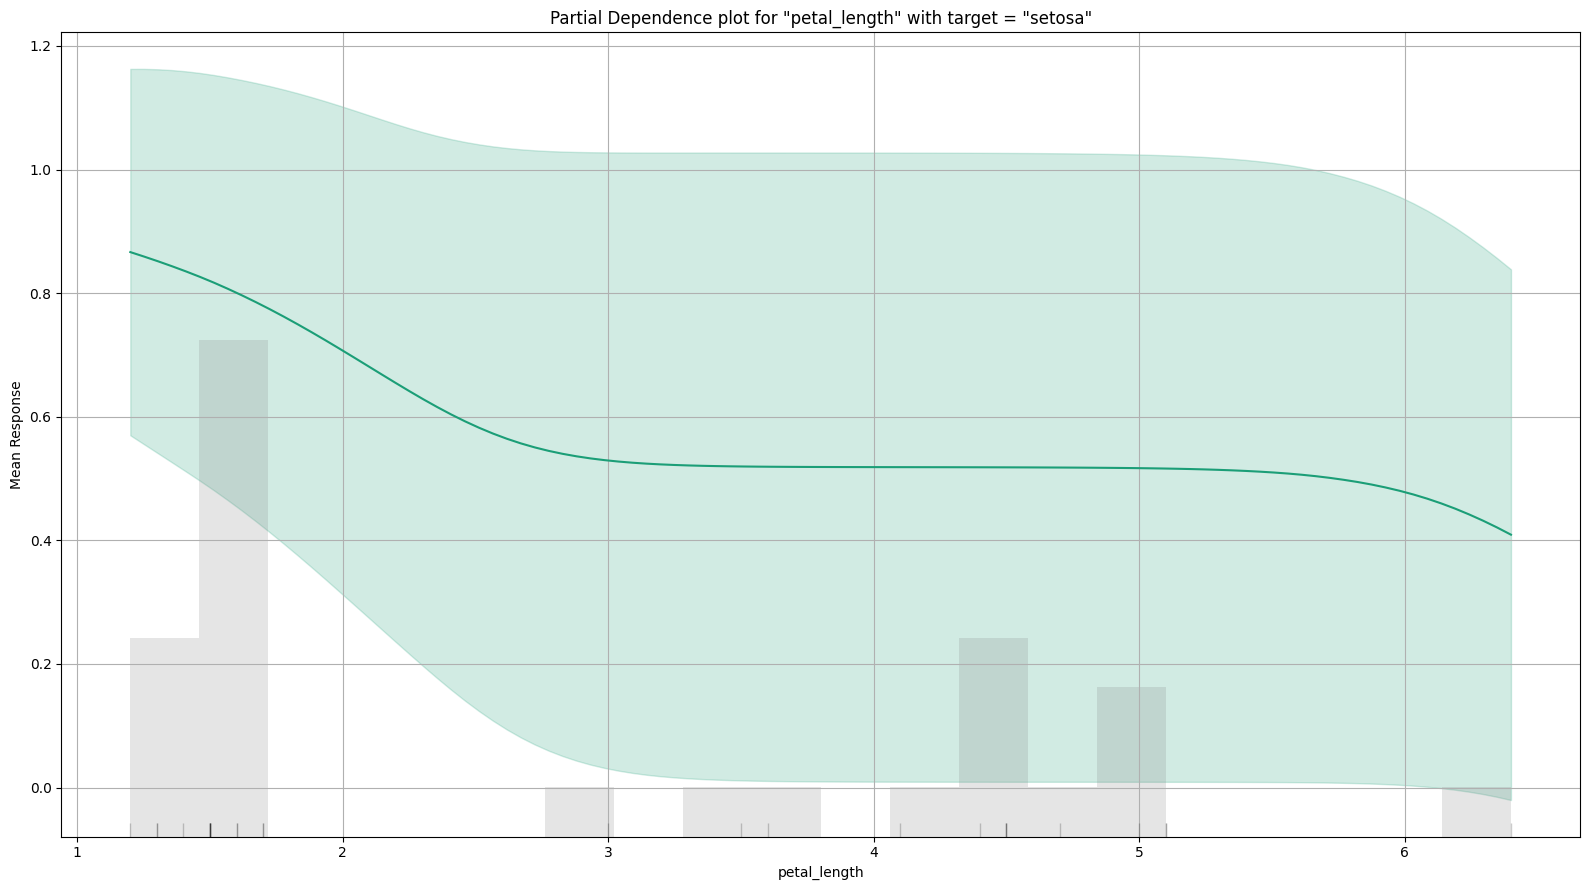

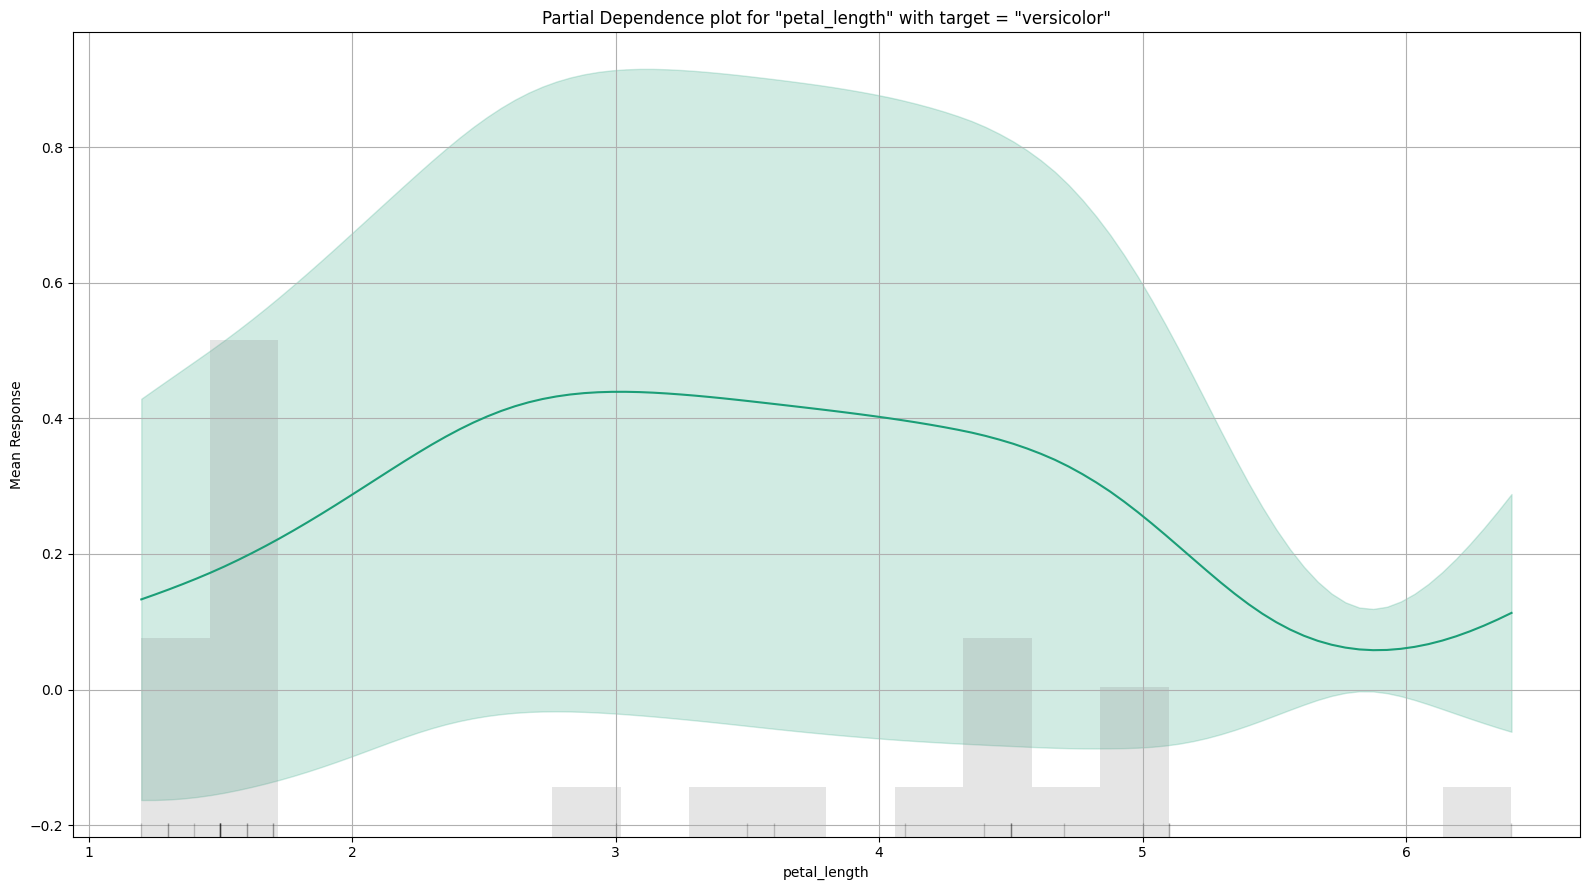

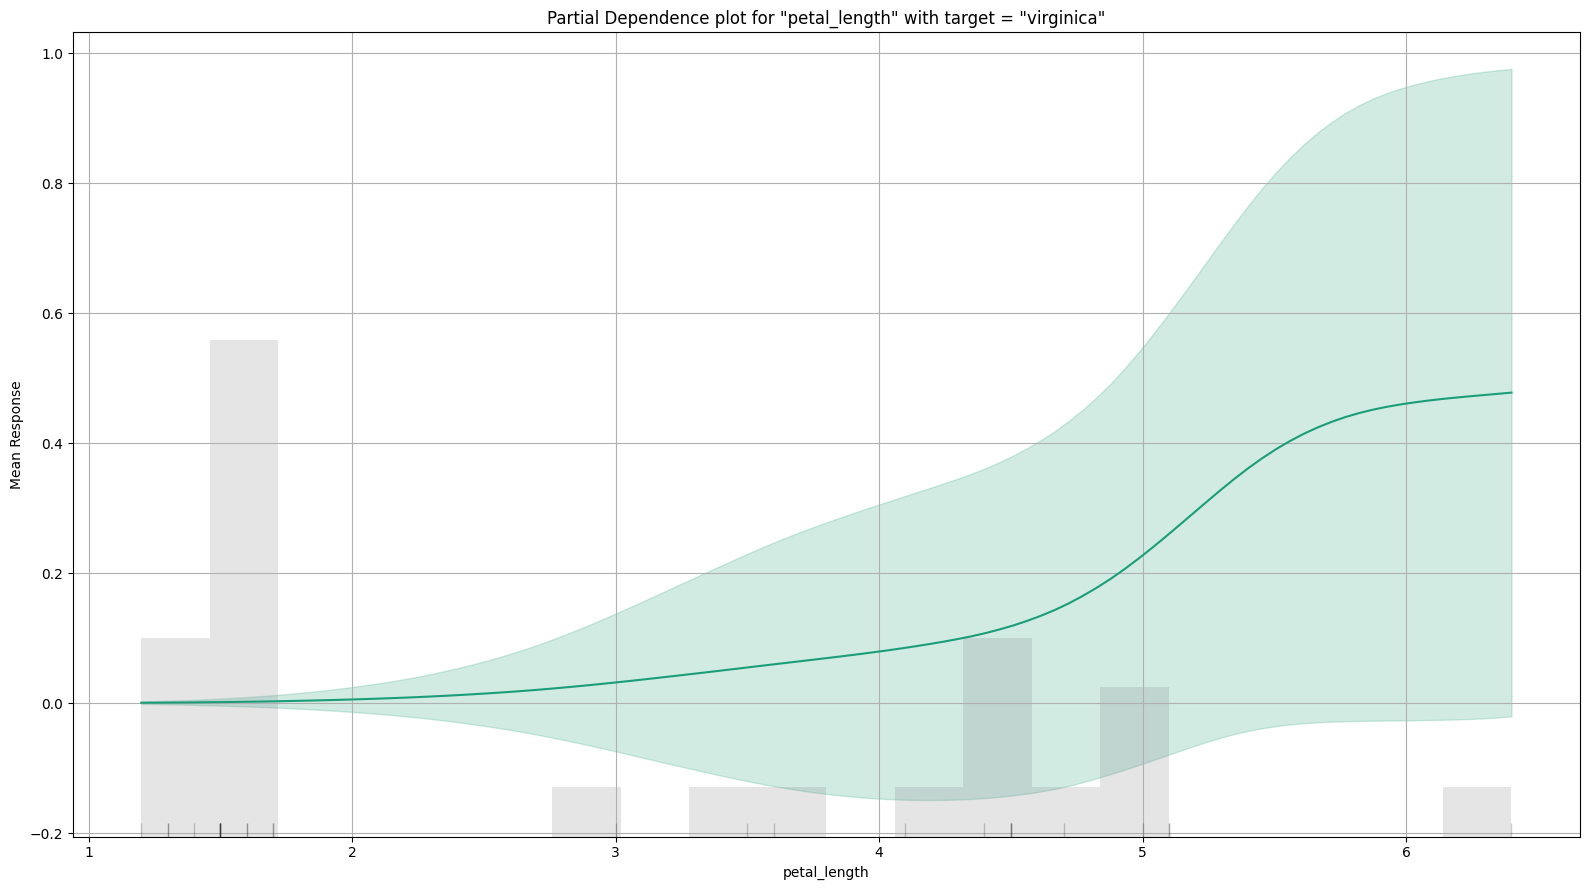

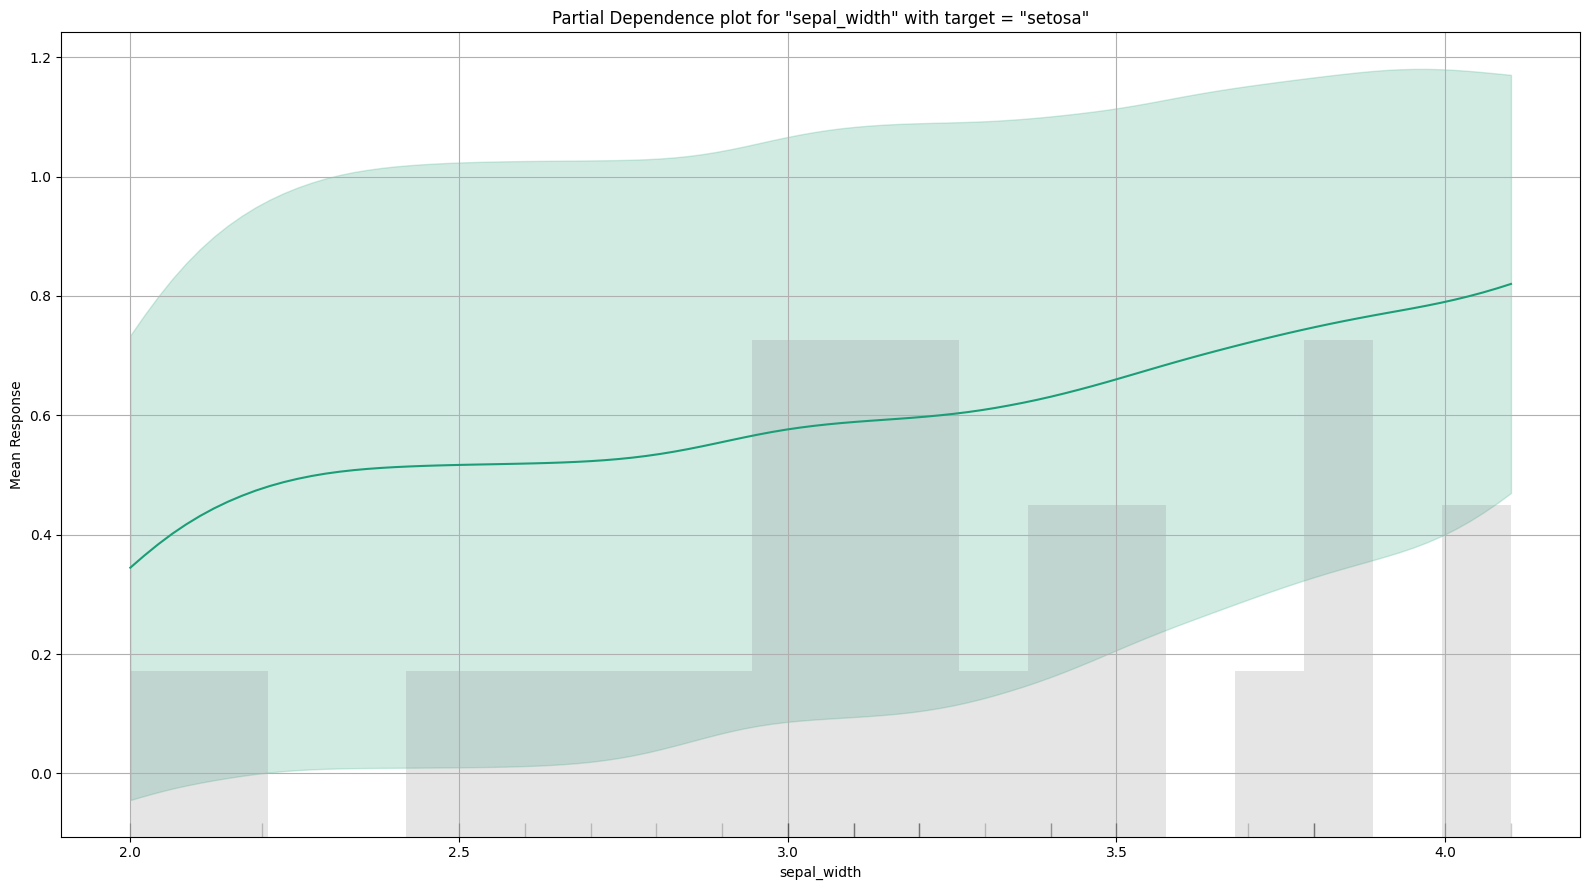

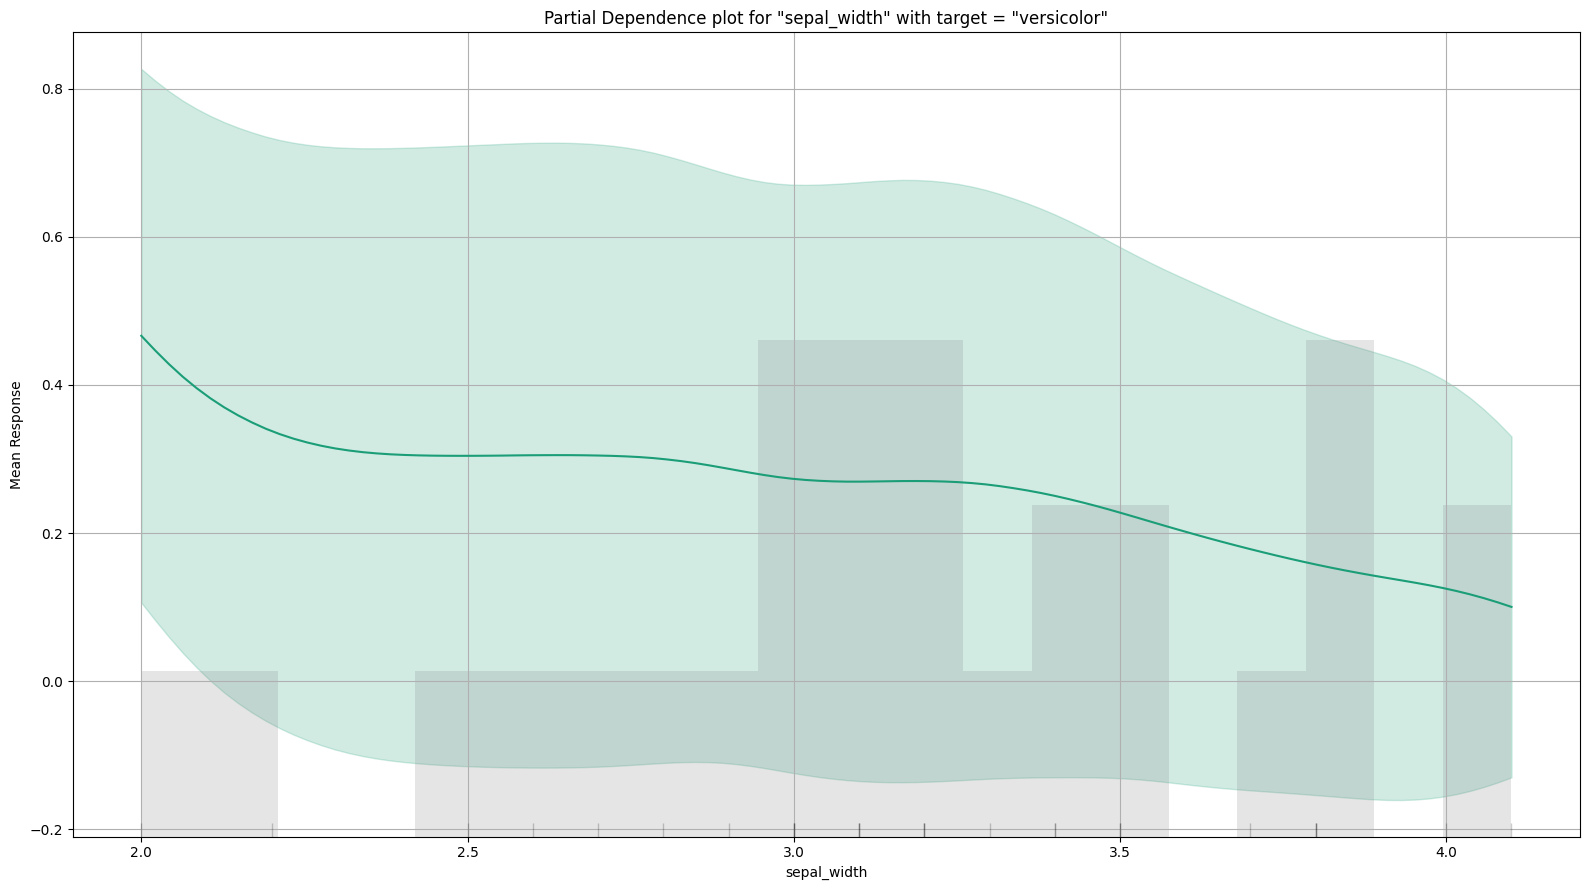

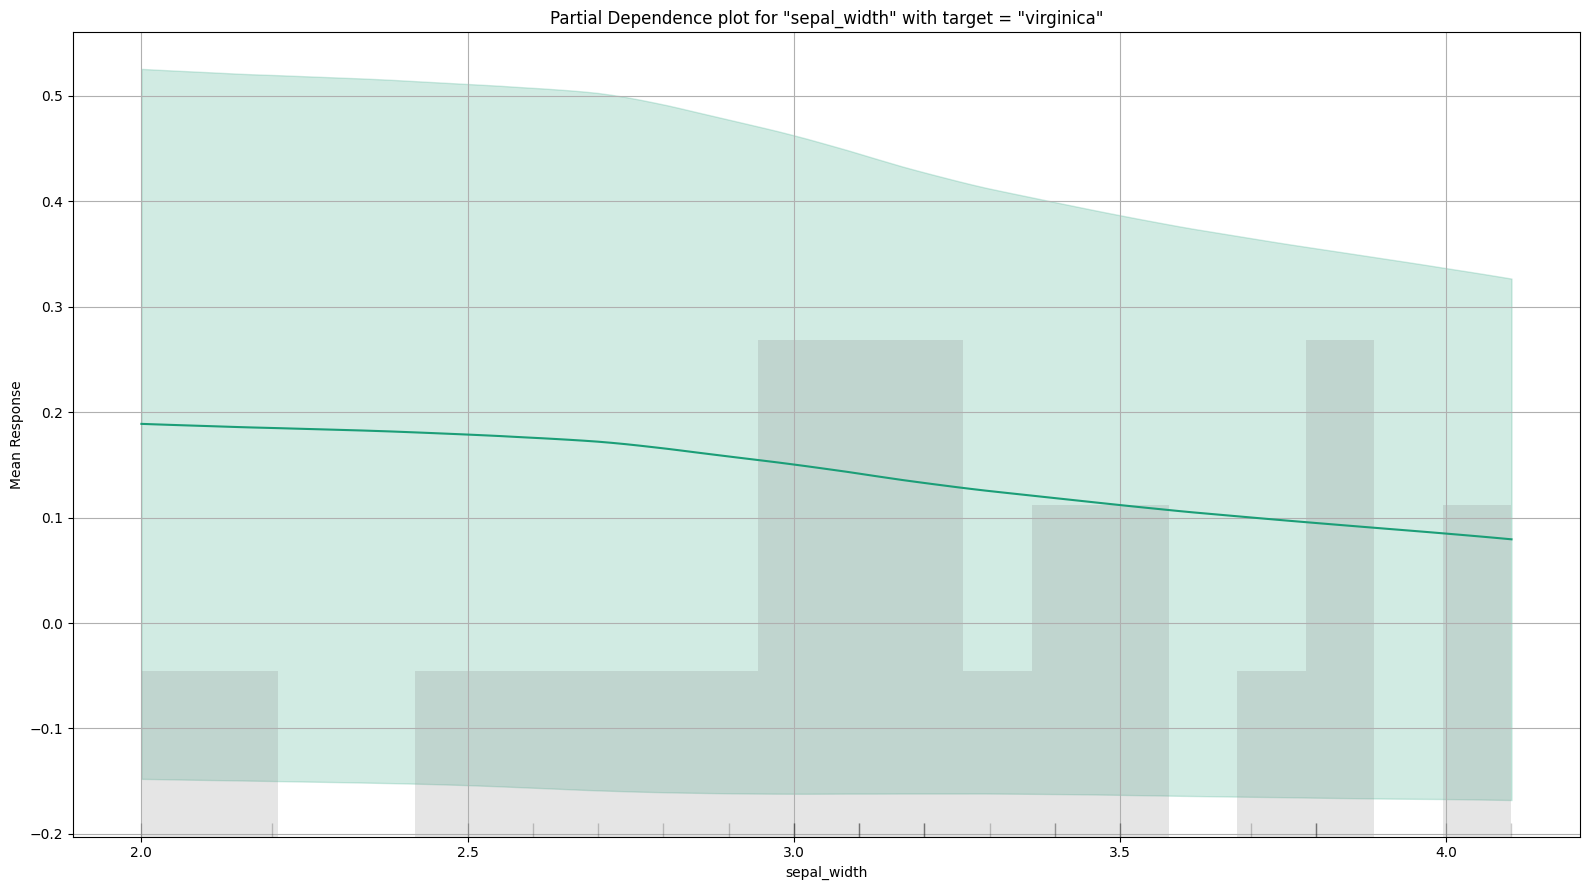

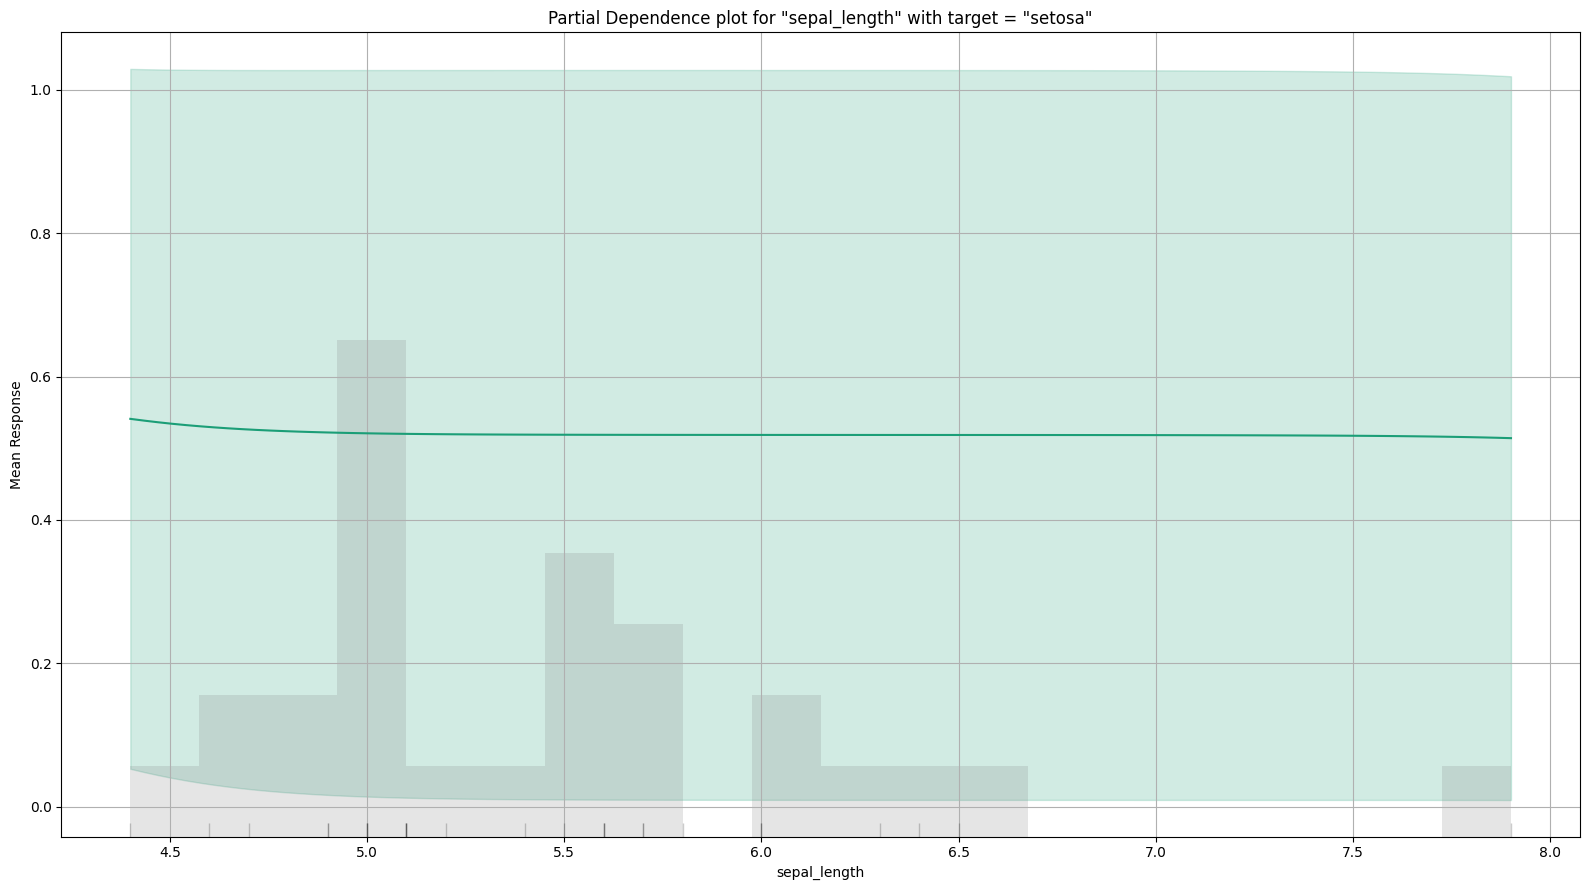

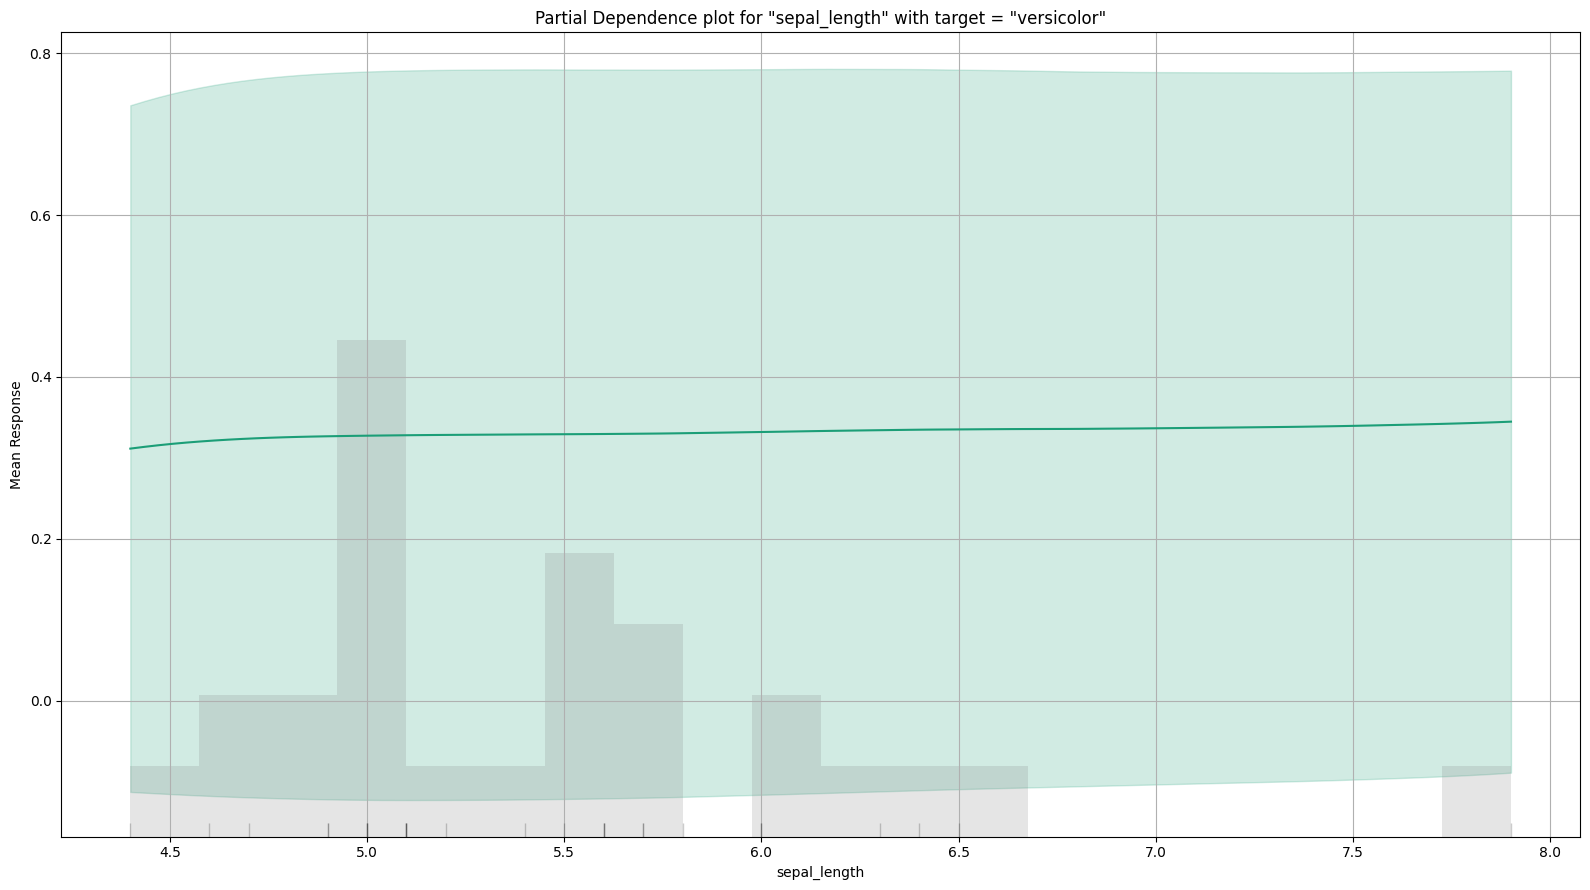

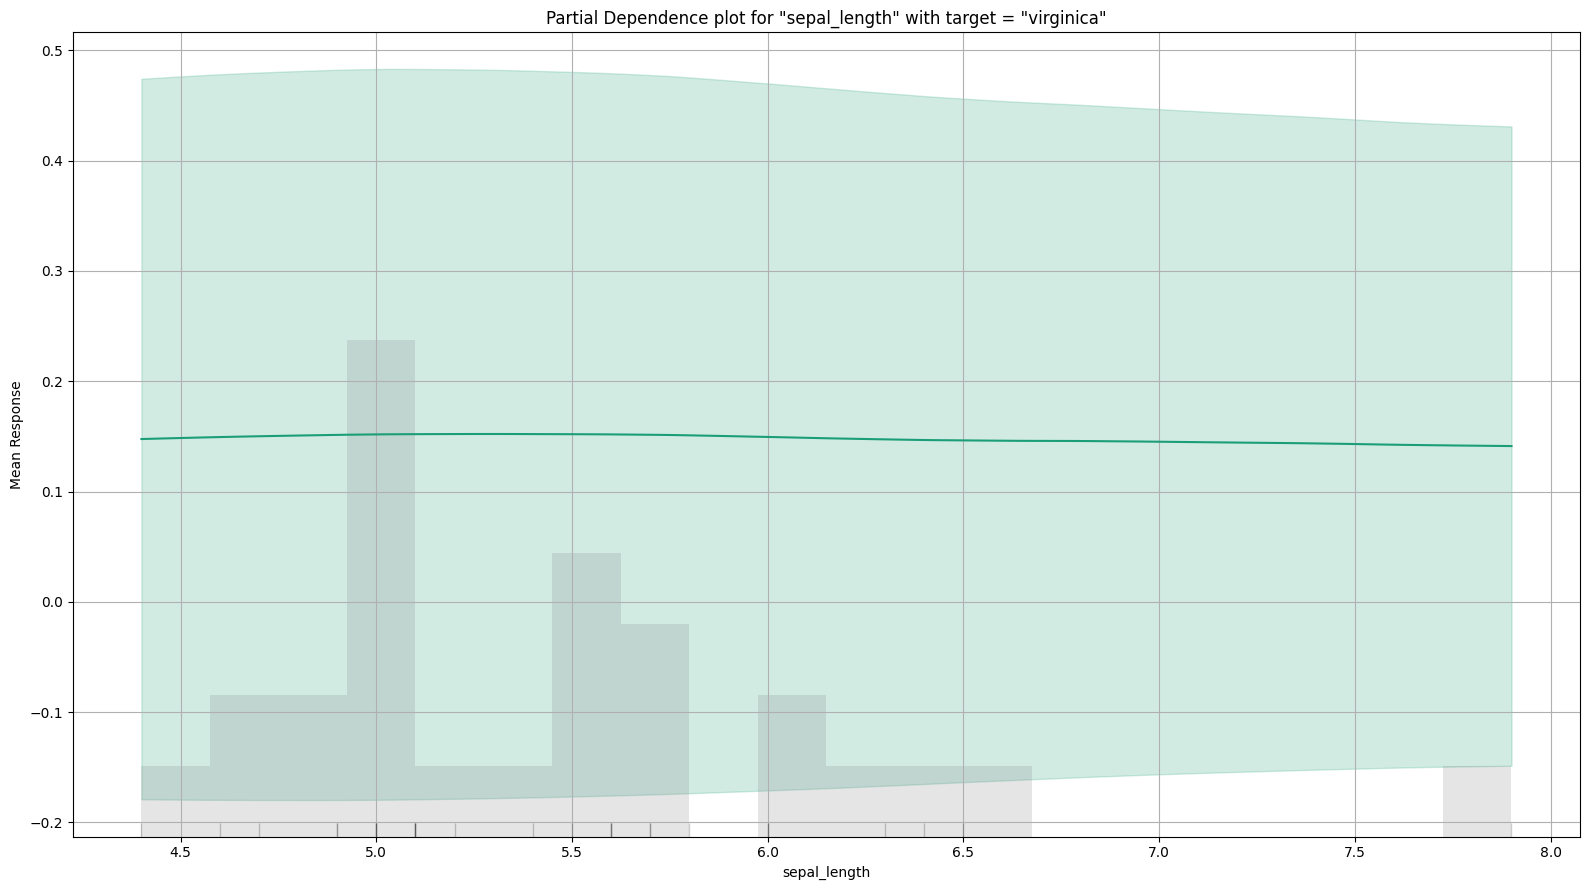

In [62]:
# Gerar explicações visuais do modelo
leader.explain(test)

### Config de 3 Modelos 

In [7]:
aml = H2OAutoML(
    max_runtime_secs=60,
    seed=1234,
    include_algos=["GLM", "GBM", "DRF"]  # só estes 3 modelos
)

aml.train(x=x, y=y, training_frame=train)

AutoML progress: |█
15:14:34.997: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 123.0.

██████████████████████████████████████████████████████████████| (done) 100%


Model Details
=============
H2OGeneralizedLinearEstimator : Generalized Linear Modeling
Model Key: GLM_1_AutoML_2_20260409_151432


GLM Model: summary
    family       link         regularization               lambda_search                                                                  number_of_predictors_total    number_of_active_predictors    number_of_iterations    training_frame
--  -----------  -----------  ---------------------------  -----------------------------------------------------------------------------  ----------------------------  -----------------------------  ----------------------  -----------------------------------------------
    multinomial  multinomial  Ridge ( lambda = 2.802E-4 )  nlambda = 30, lambda.max = 41.68, lambda.min = 2.802E-4, lambda.1se = 0.00117  15                            12                             101                     AutoML_2_20260409_151432_training_py_3_sid_bcb6

ModelMetricsMultinomialGLM: glm
** Reported on train data. **

MSE: 0.010556935162211418
RMSE: 0.10274694721601911
LogLoss: 0.04155829022447403
Null degrees of freedom: 122
Residual degrees of freedom: 108
Null deviance: 268.75975696291414
Residual deviance: 10.223339395220611
AUC table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).
AUCPR table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).

Confusion Matrix: Row labels: Actual class; Column labels: Predicted class
setosa    versicolor    virginica    Error      Rate
--------  ------------  -----------  ---------  -------
36        0             0            0          0 / 36
0         39            1            0.025      1 / 40
0         1             46           0.0212766  1 / 47
36        40            47           0.0162602  2 / 123

Top-3 Hit Ratios: 
k    hit_ratio
---  -----------
1    0.98374
2    1
3    1

ModelMetricsMultinomialGLM: glm
** Reported on cross-validation data. **

MSE: 0.025525199476644216
RMSE: 0.15976607736514098
LogLoss: 0.08029708889626898
Null degrees of freedom: 122
Residual degrees of freedom: 108
Null deviance: 268.8675474164887
Residual deviance: 19.75308386848217
AUC table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).
AUCPR table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).

Confusion Matrix: Row labels: Actual class; Column labels: Predicted class
setosa    versicolor    virginica    Error      Rate
--------  ------------  -----------  ---------  -------
36        0             0            0          0 / 36
0         37            3            0.075      3 / 40
0         2             45           0.0425532  2 / 47
36        39            48           0.0406504  5 / 123

Top-3 Hit Ratios: 
k    hit_ratio
---  -----------
1    0.95935
2    1
3    1

Cross-Validation Metrics Summary: 
                         mean       sd         cv_1_valid    cv_2_valid    cv_3_valid    cv_4_valid    cv_5_valid
-----------------------  ---------  ---------  ------------  ------------  ------------  ------------  ------------
accuracy                 0.96       0.0489898  0.96          0.96          0.88          1             1
aic                      nan        0          nan           nan           nan           nan           nan
auc                      nan        0          nan           nan           nan           nan           nan
err                      0.04       0.0489898  0.04          0.04          0.12          0             0
err_count                1          1.22474    1             1             3             0             0
loglikelihood            0          0          0             0           

In [12]:
df_f1.head(3)

,Modelo,F1_score
0,GLM_1_AutoML_2_20260409_151432,0.964634
36,GBM_grid_1_AutoML_2_20260409_151432_model_10,0.964634
1,DRF_1_AutoML_2_20260409_151432,0.925926


### Config com Ficheiro

In [14]:
import json

with open("config_h2o.json") as f:
    config = json.load(f)

aml = H2OAutoML(**config)
aml.train(x=x, y=y, training_frame=train)

AutoML progress: |█
15:33:05.713: _min_rows param, The dataset size is too small to split for min_rows=100.0: must have at least 200.0 (weighted) rows, but have only 123.0.

██████████████████████████████████████████████████████████████| (done) 100%


Model Details
=============
H2OGeneralizedLinearEstimator : Generalized Linear Modeling
Model Key: GLM_1_AutoML_3_20260409_153305


GLM Model: summary
    family       link         regularization               lambda_search                                                                  number_of_predictors_total    number_of_active_predictors    number_of_iterations    training_frame
--  -----------  -----------  ---------------------------  -----------------------------------------------------------------------------  ----------------------------  -----------------------------  ----------------------  -----------------------------------------------
    multinomial  multinomial  Ridge ( lambda = 2.802E-4 )  nlambda = 30, lambda.max = 41.68, lambda.min = 2.802E-4, lambda.1se = 0.00117  15                            12                             101                     AutoML_3_20260409_153305_training_py_3_sid_bcb6

ModelMetricsMultinomialGLM: glm
** Reported on train data. **

MSE: 0.010556935162211418
RMSE: 0.10274694721601911
LogLoss: 0.04155829022447403
Null degrees of freedom: 122
Residual degrees of freedom: 108
Null deviance: 268.75975696291414
Residual deviance: 10.223339395220611
AUC table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).
AUCPR table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).

Confusion Matrix: Row labels: Actual class; Column labels: Predicted class
setosa    versicolor    virginica    Error      Rate
--------  ------------  -----------  ---------  -------
36        0             0            0          0 / 36
0         39            1            0.025      1 / 40
0         1             46           0.0212766  1 / 47
36        40            47           0.0162602  2 / 123

Top-3 Hit Ratios: 
k    hit_ratio
---  -----------
1    0.98374
2    1
3    1

ModelMetricsMultinomialGLM: glm
** Reported on cross-validation data. **

MSE: 0.025525199476644216
RMSE: 0.15976607736514098
LogLoss: 0.08029708889626898
Null degrees of freedom: 122
Residual degrees of freedom: 108
Null deviance: 268.8675474164887
Residual deviance: 19.75308386848217
AUC table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).
AUCPR table was not computed: it is either disabled (model parameter 'auc_type' was set to AUTO or NONE) or the domain size exceeds the limit (maximum is 50 domains).

Confusion Matrix: Row labels: Actual class; Column labels: Predicted class
setosa    versicolor    virginica    Error      Rate
--------  ------------  -----------  ---------  -------
36        0             0            0          0 / 36
0         37            3            0.075      3 / 40
0         2             45           0.0425532  2 / 47
36        39            48           0.0406504  5 / 123

Top-3 Hit Ratios: 
k    hit_ratio
---  -----------
1    0.95935
2    1
3    1

Cross-Validation Metrics Summary: 
                         mean       sd         cv_1_valid    cv_2_valid    cv_3_valid    cv_4_valid    cv_5_valid
-----------------------  ---------  ---------  ------------  ------------  ------------  ------------  ------------
accuracy                 0.96       0.0489898  0.96          0.96          0.88          1             1
aic                      nan        0          nan           nan           nan           nan           nan
auc                      nan        0          nan           nan           nan           nan           nan
err                      0.04       0.0489898  0.04          0.04          0.12          0             0
err_count                1          1.22474    1             1             3             0             0
loglikelihood            0          0          0             0           

## H2O AutoML

A utilização do H2O AutoML revelou-se eficaz na identificação automática de modelos com elevado desempenho, destacando-se pela simplicidade de implementação e pela clareza dos resultados. No dataset Iris, o modelo selecionado apresentou uma taxa de erro muito reduzida e classificações praticamente perfeitas, evidenciando a capacidade da ferramenta em gerar soluções robustas de forma rápida.

Os resultados obtidos estão em linha com a análise exploratória realizada, na qual as variáveis *petal_length* e *petal_width* foram identificadas como as mais relevantes para a distinção entre classes, confirmando-se posteriormente como determinantes no processo de classificação.

No entanto, estes resultados devem ser interpretados com cautela, uma vez que o dataset utilizado apresenta elevada separabilidade entre classes e reduzida dimensão. Estas características facilitam o processo de aprendizagem, podendo limitar a avaliação do verdadeiro potencial do modelo em contextos mais complexos.

Assim, embora o H2O AutoML demonstre elevada eficiência e consistência, a sua aplicação revela-se particularmente mais relevante em problemas de maior complexidade, onde a automatização do processo de modelação pode trazer ganhos efetivos.